# Part 4
In this part we will make our model more in-line with our submission-format, mainly by transforming to cumulative weights.


In [1]:
#Imports
#must pip install holidays
import holidays
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import A_functions 
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
import random
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import os

imported functions from local folder


c:\Users\aksel\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Variables:

In [ ]:
feature_columns = [
    "day_of_week", 
    "month", 
    "is_holiday",
    "rm_id",
    ]


#Choose one or the other.
target = [
    #"cumulative_weight"
    "daily_weight"
]

In [4]:
clean_df = pd.read_csv("cleaned_data/cleaned_df_final_test.csv", parse_dates=["date"]) #TEMP NAME, remember to change.
#Variables that we need
#clean_df = clean_df.set_index('date')

#clean_df.info()

In [5]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183954 entries, 0 to 183953
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   date                        183954 non-null  datetime64[ns]
 1   day_of_week                 183954 non-null  int64         
 2   month                       183954 non-null  int64         
 3   is_holiday                  183954 non-null  int64         
 4   rm_id                       183954 non-null  float64       
 5   daily_weight                183954 non-null  float64       
 6   num_orders                  183954 non-null  float64       
 7   avg_orders                  183954 non-null  float64       
 8   max_orders                  183954 non-null  float64       
 9   std_orders                  183954 non-null  float64       
 10  num_product_ids             183954 non-null  float64       
 11  num_purchase_orders         183954 non-

# Functions

In [13]:
forecast_horizon = 165

train_df = clean_df[clean_df["date"] <= pd.Timestamp(day=19, month=12, year=2024)]
predict_df = clean_df[clean_df["date"] > pd.Timestamp(day=19, month=12, year=2024)]

print(train_df.tail())
print(predict_df.tail())

             date  day_of_week  month  is_holiday   rm_id  daily_weight  \
183786 2024-12-15            6     12           0  4501.0           0.0   
183787 2024-12-16            0     12           0  4501.0           0.0   
183788 2024-12-17            1     12           0  4501.0           0.0   
183789 2024-12-18            2     12           0  4501.0           0.0   
183790 2024-12-19            3     12           0  4501.0           0.0   

        num_orders  avg_orders  max_orders  std_orders  ...  \
183786         0.0         0.0         0.0         0.0  ...   
183787         0.0         0.0         0.0         0.0  ...   
183788         0.0         0.0         0.0         0.0  ...   
183789         0.0         0.0         0.0         0.0  ...   
183790         0.0         0.0         0.0         0.0  ...   

        num_purchase_orders  avg_purchase_order_item_no  avg_receival_item_no  \
183786                  0.0                         0.0                   0.0   
183787  

In [ ]:
def add_train_features(df, horizon):
    df["staleness"] = np.random.randint(0, horizon, size=len(df))

    processed_groups = []
    for id, group in df.groupby("rm_id", sort=False):
        rolling_7 = group.daily_weight.shift(1).rolling(7).mean()
        rolling_28 = group.daily_weight.shift(1).rolling(28).mean()
        rolling_112 = group.daily_weight.shift(1).rolling(112).mean()
        group_id = pd.DataFrame({
            "rolling_7" : rolling_7,
        })




In [20]:
train_df = add_train_features(train_df, forecast_horizon)
#print(train_df.info())
print(train_df["staleness"].tail())

183786    156
183787    142
183788     59
183789     42
183790    123
Name: staleness, dtype: int32


C:\Users\aksel\AppData\Local\Temp\ipykernel_21424\2971387249.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["staleness"] = np.random.randint(0, horizon, size=len(df))


In [ ]:
def add_rolling_features(df):
    p = 1/10 #Chosen somewhat randomly. We want our expected staleness to be somewhere around 164/2, but our prediction data will never have data more stale than 164.
    n = len(df)
    random.seed(10)
    df["bernoulli_success"] = random.choices([1,0], weights=[p, 1-p], k=n)


    processed_groups = []

    for id, group in df.groupby("rm_id"):
        #group = group.copy()
        staleness = 0
        staleness_list = []
        for success in group["bernoulli_success"]:
            if success:
                staleness = 0
            else:
                staleness += 1
            staleness_list.append(staleness)
        group["rm_id"] = id
        group["staleness"] = staleness_list
        #Rolling averages
        
        group["rolling_7_avg"] = group["daily_weight"].rolling(7).mean().where(group["bernoulli_success"] == 1)
        group["rolling_7_avg"] = group["rolling_7_avg"].ffill()

        group["rolling_30_avg"] = group["daily_weight"].rolling(30).mean().where(group["bernoulli_success"] == 1)
        group["rolling_30_avg"] = group["rolling_30_avg"].ffill()

        group["rolling_100_avg"] = group["daily_weight"].rolling(100).mean().where(group["bernoulli_success"] == 1)
        group["rolling_100_avg"] = group["rolling_100_avg"].ffill()

        group["rolling_200_avg"] = group["daily_weight"].rolling(200).mean().where(group["bernoulli_success"] == 1)
        group["rolling_200_avg"] = group["rolling_200_avg"].ffill()

        group["rolling_500_avg"] = group["daily_weight"].rolling(500).mean().where(group["bernoulli_success"] == 1)
        group["rolling_500_avg"] = group["rolling_500_avg"].ffill()

        group["rolling_7_cumulative_avg"] = group["cumulative_weight"].rolling(7).mean().where(group["bernoulli_success"] == 1)
        group["rolling_7_cumulative_avg"] = group["rolling_7_cumulative_avg"].ffill()

        group["rolling_30_cumulative_avg"] = group["cumulative_weight"].rolling(30).mean().where(group["bernoulli_success"] == 1)
        group["rolling_30_cumulative_avg"] = group["rolling_30_cumulative_avg"].ffill()

        group["rolling_100_cumulative_avg"] = group["cumulative_weight"].rolling(100).mean().where(group["bernoulli_success"] == 1)
        group["rolling_100_cumulative_avg"] = group["rolling_100_cumulative_avg"].ffill()


        #Frequencies
        group["rolling_7_freq"] = (group['daily_weight'] != 0).rolling(window=7).mean().where(group["bernoulli_success"] == 1)
        group["rolling_7_freq"] = group["rolling_7_freq"].ffill()

        group["rolling_30_freq"] = (group['daily_weight'] != 0).rolling(window=30).mean().where(group["bernoulli_success"] == 1)
        group["rolling_30_freq"] = group["rolling_30_freq"].ffill()

        group["rolling_100_freq"] = (group['daily_weight'] != 0).rolling(window=100).mean().where(group["bernoulli_success"] == 1)
        group["rolling_100_freq"] = group["rolling_100_freq"].ffill()


        #Lagged rolling averages
        group["shifted_30_rolling_7_avg"] = group["daily_weight"].shift(30).rolling(7).mean().where(group["staleness"] <= 30)
        group["shifted_30_rolling_7_avg"] = group["shifted_30_rolling_7_avg"].ffill()

        group["shifted_100_rolling_7_avg"] = group["daily_weight"].shift(100).rolling(7).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_7_avg"] = group["shifted_100_rolling_7_avg"].ffill()

        group["shifted_100_rolling_30_avg"] = group["daily_weight"].shift(30).rolling(30).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_30_avg"] = group["shifted_100_rolling_30_avg"].ffill()


        #Lagged frequencies
        group["shifted_30_rolling_7_freq"] = (group['daily_weight'].shift(30) != 0).rolling(window=7).mean().where(group["staleness"] <= 30)
        group["shifted_30_rolling_7_freq"] = group["shifted_30_rolling_7_freq"].ffill()

        group["shifted_100_rolling_7_freq"] = (group['daily_weight'].shift(100) != 0).rolling(window=7).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_7_freq"] = group["shifted_100_rolling_7_freq"].ffill()

        group["shifted_100_rolling_30_freq"] = (group['daily_weight'].shift(100) != 0).rolling(window=30).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_30_freq"] = group["shifted_100_rolling_30_freq"].ffill()

    
        #We must include "true" values as well, although these are not used as features, we will use them by the prediction maps.
        group["true_rolling_7_avg"] = group["daily_weight"].rolling(7).mean()
        group["true_rolling_30_avg"] = group["daily_weight"].rolling(30).mean()
        group["true_rolling_100_avg"] = group["daily_weight"].rolling(100).mean()
        group["true_rolling_200_avg"] = group["daily_weight"].rolling(200).mean()
        group["true_rolling_500_avg"] = group["daily_weight"].rolling(500).mean()
        group["true_rolling_7_cumulative_avg"] = group["cumulative_weight"].rolling(7).mean()
        group["true_rolling_30_cumulative_avg"] = group["cumulative_weight"].rolling(30).mean()
        group["true_rolling_100_cumulative_avg"] = group["cumulative_weight"].rolling(100).mean()


        group["true_rolling_7_freq"] = (group['daily_weight'] != 0).rolling(window=7).mean()
        group["true_rolling_30_freq"] = (group['daily_weight'] != 0).rolling(window=30).mean()
        group["true_rolling_100_freq"] = (group['daily_weight'] != 0).rolling(window=100).mean()

        processed_groups.append(group)

    df = pd.concat(processed_groups)

    return df

In [567]:
def add_more_features(df):
    

    df["rolling_7_short_decay"] = df["rolling_7_avg"] * np.exp(-df["staleness"]/10)
    df["rolling_30_medium_decay"] = df["rolling_30_avg"] * np.exp(-df["staleness"]/50)
    df["rolling_100_long_decay"] = df["rolling_100_avg"] * np.exp(-df["staleness"]/150)
    df["rolling_7_medium_decay"] = df["rolling_7_avg"] * np.exp(-df["staleness"]/50)
    df["rolling_30_long_decay"] = df["rolling_30_avg"] * np.exp(-df["staleness"]/150)
    df["rolling_100_very_long_decay"] = df["rolling_100_avg"] * np.exp(-df["staleness"]/300)

    df["rolling_7_noise"] = df["rolling_7_avg"] + (random.uniform(-1, 1) * (df["rolling_7_avg"]) * df["staleness"])
    df["rolling_30_noise"] = df["rolling_30_avg"] + (random.uniform(-1, 1) * (df["rolling_30_avg"]) * df["staleness"])
    df["rolling_100_noise"] = df["rolling_100_avg"] + (random.uniform(-1, 1) * (df["rolling_100_avg"]) * df["staleness"])

    df["rolling_7_decay"] = df["rolling_7_avg"] * np.exp(-df["staleness"]/10) + (np.random.uniform(-1, 1, size=len(df)) * (df["rolling_7_avg"]) * df["staleness"]/100)
    df["rolling_30_decay"] = df["rolling_30_avg"] * np.exp(-df["staleness"]/50) + (np.random.uniform(-1, 1, size=len(df)) * (df["rolling_30_avg"]) * df["staleness"]/100)
    df["rolling_100_decay"] = df["rolling_100_avg"] * np.exp(-df["staleness"]/150) + (np.random.uniform(-1, 1, size=len(df)) * (df["rolling_100_avg"]) * df["staleness"]/100)
    #df["7/30"] =  df["rolling_7_decay"]/df["rolling_30_decay"]
    #df["30/100"] = df["rolling_30_decay"]/df["rolling_100_decay"]
    df["freq_x_7"] = df["rolling_7_decay"]*df["rolling_7_freq"]
    df["freq_x_30"] = df["rolling_30_decay"]*df["rolling_30_freq"]
    df["freq_x_100"] = df["rolling_100_decay"]*df["rolling_100_freq"]

    df["rolling_7_cumulative_decay"] = df["rolling_7_cumulative_avg"] / df["staleness"]
    df["rolling_30_cumulative_decay"] = df["rolling_30_cumulative_avg"] / df["staleness"]
    df["rolling_100_cumulative_decay"] = df["rolling_100_cumulative_avg"] / df["staleness"]

    df["rolling_7_cumulative_short_decay"] = df["rolling_7_cumulative_avg"] * np.exp(-df["staleness"]/10)
    df["rolling_7_cumulative_medium_decay"] = df["rolling_7_cumulative_avg"] * np.exp(-df["staleness"]/50)
    df["rolling_30_cumulative_medium_decay"] = df["rolling_30_cumulative_avg"] * np.exp(-df["staleness"]/50)
    df["rolling_30_cumulative_long_decay"] = df["rolling_30_cumulative_avg"] * np.exp(-df["staleness"]/100)
    df["rolling_100_cumulative_long_decay"] = df["rolling_100_cumulative_avg"] * np.exp(-df["staleness"]/100)


    df["shifted_30_rolling_7_short_decay"] = df["shifted_30_rolling_7_avg"] * np.exp(-(df["staleness"]-30)/10)
    df["shifted_100_rolling_7_medium_decay"] = df["shifted_100_rolling_7_avg"] * np.exp(-(df["staleness"]-100)/50)
    df["shifted_100_rolling_30_medium_decay"] = df["shifted_100_rolling_30_avg"] * np.exp(-(df["staleness"]-100)/50)

    return df

In [10]:
def prepare_common_map(start_date, end_date):
    
    prediction_range = pd.date_range(start=start_date, end=end_date)

    common_map = pd.DataFrame({"datetime" : prediction_range})
    common_map["datetime"] = pd.to_datetime(common_map["datetime"]).dt.tz_localize(None)
    common_map["datetime"] = common_map["datetime"].dt.normalize()
    #common_map["date"] = common_map["datetime"].dt.date
    common_map["day_of_week"] = common_map["datetime"].dt.dayofweek
    common_map["month"] = common_map["datetime"].dt.month

    years = list(range(2023, 2025))
    all_holidays = holidays.Norway(years = years)
    
    #Convert type
    all_holidays = list(all_holidays.keys())
    all_holidays = pd.to_datetime(all_holidays)
    all_holidays = pd.DataFrame({"holidays" : all_holidays})
    #Mark holidays
    common_map["is_holiday"] = common_map["datetime"].isin(all_holidays["holidays"])
    common_map["is_holiday"] = common_map["is_holiday"].astype(int)
    print(common_map["is_holiday"].sum() ," days are marked as holidays")

    common_map["staleness"] = range(0,len(common_map))
    
    return common_map
    
    


In [236]:
def prepare_full_map(common_map, df):

    processed_groups = []
    for id, group in df.groupby("rm_id"):
        id_map = common_map.copy()
        id_map["rm_id"] = id

        #Rolling averages
        id_map["rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-1]
        id_map["rolling_30_avg"] = group["true_rolling_30_avg"].iloc[-1]
        id_map["rolling_100_avg"] = group["true_rolling_100_avg"].iloc[-1]
        id_map["rolling_200_avg"] = group["true_rolling_200_avg"].iloc[-1]
        id_map["rolling_500_avg"] = group["true_rolling_500_avg"].iloc[-1]

        id_map["rolling_7_cumulative_avg"] = group["true_rolling_7_cumulative_avg"].iloc[-1]
        id_map["rolling_30_cumulative_avg"] = group["true_rolling_30_cumulative_avg"].iloc[-1]
        id_map["rolling_100_cumulative_avg"] = group["true_rolling_100_cumulative_avg"].iloc[-1]

        #Frequencies
        id_map["rolling_7_freq"] = group["true_rolling_7_freq"].iloc[-1]
        id_map["rolling_30_freq"] = group["true_rolling_30_freq"].iloc[-1]
        id_map["rolling_100_freq"] = group["true_rolling_100_freq"].iloc[-1]

        #Lagged rolling averages
        id_map["shifted_30_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-1]
        id_map.loc[id_map.index[:30], "shifted_30_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-30:].values

        id_map["shifted_100_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-100:].values

        id_map["shifted_100_rolling_30_avg"] = group["true_rolling_30_avg"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_30_avg"] = group["true_rolling_30_avg"].iloc[-100:].values

        #Lagged frequencies
        id_map["shifted_30_rolling_7_freq"] = group["rolling_7_freq"].iloc[-1]
        id_map.loc[id_map.index[:30], "shifted_30_rolling_7_freq"] = group["true_rolling_7_freq"].iloc[-30:].values

        id_map["shifted_100_rolling_7_freq"] = group["rolling_7_freq"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_7_freq"] = group["true_rolling_7_freq"].iloc[-100:].values

        id_map["shifted_100_rolling_30_freq"] = group["rolling_30_freq"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_30_freq"] = group["true_rolling_30_freq"].iloc[-100:].values


        processed_groups.append(id_map)

    full_map = pd.concat(processed_groups)

    full_map = add_more_features(full_map)

    return full_map

In [292]:
def split_data(df, feature_columns, target):
    df["datetime"] = pd.to_datetime(df["datetime"])
    
    #Two main splits: Future and Test.
    #Future is further split into train and eval.
    #eval-1 is 20.12.2023 - 31.05.2024
    future_eval1_start = pd.Timestamp(day=20, month=12, year=2023)
    future_eval1_stop = pd.Timestamp(day=31, month=5, year=2024)
    future_eval1 = df[((df["datetime"] >= future_eval1_start) & (df["datetime"] <= future_eval1_stop))]
    
    #eval-2 is   09.07.2024 - 19.12.2024
    future_eval2_start = pd.Timestamp(day=9, month=7, year=2024)
    future_eval2_stop = pd.Timestamp(day=19, month=12, year=2024)
    future_eval2 = df[((df["datetime"] >= future_eval2_start) & (df["datetime"] <= future_eval2_stop))]

    #Future predict area is 01.01.2025 - 31.05.2025
    future_predict_start = pd.Timestamp(day=20, month=12, year=2024)
    future_predict_stop = pd.Timestamp(day=31, month=5, year=2025)
    #We create the prediction map that we will pass to the model for prediction.

    future_predict = prepare_common_map(future_predict_start, future_predict_stop)
    future_predict = prepare_full_map(future_predict, df)


    #We split into training and eval sets to features (X) and targets(y)
    future_train_full = df.copy()
    X_future_train_full = future_train_full[feature_columns]
    y_future_train_full = future_train_full[target]
    

    #Future train is the subset that will be used for training during hyperparameter tuning
    future_train = df[df["datetime"] < future_eval1_start]
    X_future_train = future_train[feature_columns]
    y_future_train = future_train[target]

    #Eval 1
    X_future_eval1 = future_eval1[feature_columns]
    y_future_eval1 = future_eval1[target]
    #Eval 2
    X_future_eval2 = future_eval2[feature_columns]
    y_future_eval2 = future_eval2[target]
    #And append to single set.
    future_eval_set = [(X_future_eval1, y_future_eval1), (X_future_eval2, y_future_eval2)]

    
    #Test is split into a similar structure.
    #Eval 1: 09.07.2023 - 19.12.2023
    test_eval1_start = pd.Timestamp(day=9, month=7, year=2023)
    test_eval1_stop = pd.Timestamp(day=19, month=12, year=2023)
    test_evalx = df[((df["datetime"] >= test_eval1_start) & (df["datetime"] <= test_eval1_stop))] ######
    test_evalx = test_evalx.reset_index()

    #Again, we split into featuers and targets
    #test_train_full = df[df["datetime"] <= test_eval2_stop]
    ###
    eval1_prep = df[df["datetime"] < test_eval1_start]
    test_eval1 = prepare_common_map(test_eval1_start, test_eval1_stop)
    test_eval1 = prepare_full_map(test_eval1, eval1_prep)
    test_eval1["daily_weight"] = test_evalx["daily_weight"]
    ###
    #Eval 2: 20.12.2023 - 31.05.2024
    test_eval2_start = pd.Timestamp(day=20, month=12, year=2023)
    test_eval2_stop = pd.Timestamp(day=31, month=5, year=2024)
    test_evaly = df[((df["datetime"] >= test_eval2_start) & (df["datetime"] <= test_eval2_stop))]  #######################
    test_evaly.to_csv("testevaly.csv", index=False)
    test_evaly = test_evaly.reset_index()
    print(test_evaly["daily_weight"])
    ###
    eval2_prep = df[df["datetime"] < test_eval2_start]
    test_eval2 = prepare_common_map(test_eval2_start, test_eval2_stop)
    test_eval2 = prepare_full_map(test_eval2, eval2_prep)
    test_eval2["daily_weight"] = test_evaly["daily_weight"]
    test_eval2.to_csv("testeval2.csv", index=False)
    
    ###
    #test predict area is 09.07.2024 - 19.12.2024
    test_predict_start = pd.Timestamp(day=9, month=7, year=2024)
    test_predict_stop = pd.Timestamp(day=19, month=12, year=2024)
    #Get map of predict area
    test_predict = prepare_common_map(test_predict_start, test_predict_stop)
    test_predict = prepare_full_map(test_predict, df)


    #Again, we split into featuers and targets
    test_train_full = df[df["datetime"] <= test_eval2_stop]
    X_test_train_full = test_train_full[feature_columns]
    y_test_train_full = test_train_full[target]

    #Training set for tuning
    test_train = df[df["datetime"] < test_eval1_start]
    X_test_train = test_train[feature_columns]
    y_test_train = test_train[target]

    #Split remaining eval sets
    X_test_eval1 = test_eval1[feature_columns]
    y_test_eval1 = test_eval1[target]
    X_test_eval2 = test_eval2[feature_columns]
    y_test_eval2 = test_eval2[target]
    test_eval_set = [(X_test_eval1, y_test_eval1), (X_test_eval2, y_test_eval2)]

    return X_future_train, y_future_train, future_eval_set, X_future_train_full, y_future_train_full, future_predict, X_test_train, y_test_train, test_eval_set, X_test_train_full, y_test_train_full, test_predict

In [17]:
def pinball_tau20(pred, true):
    diff = true - pred
    # max(0.2*(A - F), 0.8*(F - A))
    return np.maximum(0.2*diff, 0.8*(-diff))

In [ ]:
def fit_model(X_train, y_train, eval_set, X_train_full, y_train_full):

    def objective(trial):
        # Suggest hyperparameters
        params = {
            'objective' : 'quantile',
            'alpha' : 0.2,
            'metric' : 'quantile',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'num_leaves' : trial.suggest_int('num_leaves', 20, 100),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'verbose': -1,
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),

        }
        
        X_eval1, y_eval1 = eval_set[0]
        X_eval2, y_eval2 = eval_set[1]
        
        model = lgb.LGBMRegressor(**params)
        
        model.fit(
            X_train,
            y_train.values.ravel(),
            eval_set=[(X_eval1, y_eval1.values.ravel()), (X_eval2, y_eval2.values.ravel())],
            #eval_set=[(X_eval2, y_eval2.values.ravel())],
            eval_names=['eval1', 'eval2'],
        )

        preds1 = model.predict(X_eval1)
        preds2 = model.predict(X_eval2)

        #
        preds1 = preds1.cumsum()
        preds2 = preds2.cumsum()
        y_eval1 = y_eval1.cumsum()
        y_eval2 = y_eval2.cumsum()
        #

        #qpl1 = np.percentile(pinball_tau20(preds1, y_eval1.values.ravel()), 99)
        #qpl2 = np.percentile(pinball_tau20(preds2, y_eval2.values.ravel()), 99)
        qpl1 = np.mean(pinball_tau20(preds1, y_eval1.values.ravel()))
        qpl2 = np.mean(pinball_tau20(preds2, y_eval2.values.ravel()))
        #qpl1 = np.sum(pinball_tau20(preds1, y_eval1.values.ravel()))
        #qpl2 = np.sum(pinball_tau20(preds2, y_eval2.values.ravel()))
        return (qpl1 + qpl2) / 2

    # Run the optimization
    X_train.to_csv("X_train-observe.csv")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, show_progress_bar=False, n_trials=20)

    # Best parameters
    print("Best parameters:", study.best_params)


    custom_params = {
        'objective': 'quantile',
        'alpha': 0.2 ,
        'metric' : 'quantile',
    }


    final_model = lgb.LGBMRegressor(**study.best_params, **custom_params)

    final_model.fit(
        X_train_full,
        y_train_full.values.ravel(),
    )

    lgb.plot_importance(final_model, importance_type="gain", max_num_features=10)

    return final_model

In [ ]:
"""def fit_model(X_train, y_train, eval_set, X_train_full, y_train_full):

    def objective(trial):
        # Suggest hyperparameters
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        }


        X_eval1, y_eval1 = eval_set[0]
        X_eval2, y_eval2 = eval_set[1]


        
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train ,
            y_train.values.ravel(), 
            eval_set=[(X_eval1, y_eval1.values.ravel()), (X_eval2, y_eval2.values.ravel())], 
            verbose=False   
        )

        preds1 = model.predict(X_eval1)
        preds2 = model.predict(X_eval2)

        rmse1 = root_mean_squared_error(y_eval1.values.ravel(), preds1)
        rmse2 = root_mean_squared_error(y_eval2.values.ravel(), preds2)
        return (rmse1 + rmse2)/2
    # Run the optimization
    X_train.to_csv("X_train-observe.csv")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, show_progress_bar=True, n_trials=10)

    # Best parameters
    print("Best parameters:", study.best_params)

    final_model = XGBRegressor(**study.best_params)

    final_model.fit(
        X_train_full,
        y_train_full.values.ravel(),
        verbose=False
    )

    xgb.plot_importance(final_model, importance_type="gain", show_values=False, max_num_features=10)

    return final_model """


In [228]:
def apply_predict_to_map(model, prediction_map, feature_columns, target):

    processed_groups = []
    for ids, group in prediction_map.groupby("rm_id"):
        id_predictions = group.copy()
        id_predictions["rm_id"] = ids
        predictions = model.predict(id_predictions[feature_columns])

        id_predictions["predicted_net"] = predictions
        if target == ["cumulative_weight"]:
            id_predictions["predicted_cumulative"] = id_predictions["predicted_net"]
            print("target confirmed to be cumulative weight")
        else:
            id_predictions["predicted_cumulative"] = id_predictions["predicted_net"].cumsum()

        processed_groups.append(id_predictions)

    predictions = pd.concat(processed_groups)
    #predictions.to_csv("test_ids.csv")
    
    return predictions

In [259]:
def visualize(df, predictions):
    sns.set_theme()
    row = 0
    row_max = len(df["rm_id"].unique())
    print(row_max)

    fig, axes = plt.subplots(row_max, 2 ,figsize=(12, 5*row_max))
    axes = np.atleast_2d(axes)

    plt.subplots_adjust(wspace=0.5, hspace=0.6)
    
    #if row_max == 1:
        #axes = [axes]
    day = pd.Timedelta(days=1)
    for id, group in df.groupby("rm_id"):

        true_x = group["datetime"]
        true_cumulative_weight = group["cumulative_weight"]


        id_predictions = predictions[predictions["rm_id"] == id]
        id_predictions_x = id_predictions["datetime"]
        start_prediction = id_predictions_x.min()-day
        slaice = group[group["datetime"] == start_prediction]
        cumulative_baseline = slaice["cumulative_weight"].iloc[0]

        id_predictions_cumulative_weight = id_predictions["predicted_cumulative"] + cumulative_baseline

        ax = axes[row,0]
        ax.plot(true_x, true_cumulative_weight)
        ax.plot(id_predictions_x.iloc[-500:], id_predictions_cumulative_weight.iloc[-500:])

        ax_zoom = axes[row,1]
        ax_zoom.plot(true_x.iloc[-500:], true_cumulative_weight.iloc[-500:])
        ax_zoom.plot(id_predictions_x.iloc[-500:], id_predictions_cumulative_weight.iloc[-500:])

        fig.text(
        0.5,
        1,
        f"Visualization: {id} ", 
        fontsize=16, 
        weight='bold', 
        ha = "center", 
        va = "top"
        )
        row += 1

    plt.show()

    return True

        
        



In [489]:
def init_eval_file(clean_df, file_path, date_before_prediction):

    if os.path.exists(file_path):
        print("retrieved evaluation files from files")
        return(pd.read_csv(file_path, parse_dates=["datetime"]))

    processed_groups = []
    for ids, group in clean_df.groupby("rm_id", sort=False):
        baseline = group[group["datetime"] == date_before_prediction]["cumulative_weight"].iloc[0]
        test_dates = group[group["datetime"] > date_before_prediction]

        id_eval = pd.DataFrame({
            "datetime" : test_dates["datetime"],
            "rm_id" : ids,
            "true_weight" : test_dates["cumulative_weight"] - baseline,
            "predicted_weight" : 0
            })
    
        processed_groups.append(id_eval)
    eval_file = pd.concat(processed_groups)
    
    eval_file.to_csv("submissions/test_data/test_eval_file.csv", index=False)
    print("initialized evaluation file")
    return eval_file
    

#true_test_weights = initialize_test_prediction_file(clean_df, file_path="submissions/test_data/test_eval_file.csv")

In [137]:
def evaluate_test(test_prediction_file , return_details = True):
    test_prediction_file = test_prediction_file.sort_values(["datetime", "rm_id"])

    last_rows = test_prediction_file.groupby(["rm_id", "datetime"], as_index=False).tail(1)

    ql = pinball_tau20(last_rows["predicted_weight"].values, last_rows["true_weight"].values)
    last_rows = last_rows.assign(quantile_loss_0p2=ql)

    overall = float(np.mean(ql)) if len(ql) else np.nan

    
    if return_details:
        # Per-id mean (optional diagnostic)
        per_id = last_rows.groupby("rm_id")["quantile_loss_0p2"].mean().reset_index(name="mean_loss")
        return overall, last_rows[["rm_id", "datetime", "quantile_loss_0p2"]], per_id
    return overall

    

In [490]:
def add_predicts_to_eval_file(prediction_map, evaluation_file, date_before_prediction):
    processed_groups = []
    for id, group in prediction_map.groupby("rm_id", sort = False):
        baseline = group[group["datetime"] == date_before_prediction]["predicted_cumulative"].iloc[0]
        print("baseline correct: ", baseline)
        reduced_map = pd.DataFrame({
            "datetime" : group["datetime"],
            "rm_id" : id,
            "predicted_weight" : group["predicted_cumulative"] - baseline
        })
        #print(reduced_map["predicted_weight"])
        processed_groups.append(reduced_map)
        #print(reduced_map.info())

    reduced_map = pd.concat(processed_groups)

    #print("reduced map: ", reduced_map.head(15))
    #print("===========================")
    #print("===========================")
    #print("evaluation file", evaluation_file.head(1))

    reduced_map = reduced_map.set_index(["rm_id", "datetime"])
    evaluation_file = evaluation_file.set_index(["rm_id", "datetime"])


    evaluation_file.update(reduced_map)

    evaluation_file = evaluation_file.reset_index()

    evaluation_file.to_csv("submissions/test_data/test_eval_file.csv", index=False)

    return evaluation_file

In [491]:
def run(clean_df, important_days, important_ids, feature_columns, target):
    df = clean_df.copy()
    
    #First we find which rm-id's are the biggest contributors
    top_ids = find_most_important(df, important_days)
    print(top_ids.head(n=3))
    print("top 5 stands for ", top_ids.head(n=5)["proportion"].sum(), "%")
    print("top 10 stands for ", top_ids.head(n=10)["proportion"].sum(),"%")
    print("top 20 stands for ", top_ids.head(n=20)["proportion"].sum(),"%")
    print("---------------------------")
    print("find most important: Check!")
    print("===========================")

    df = filter_rows(top_ids, important_ids, df)
    print("filter rows: Check!")
    print("===========================")
    #df.to_csv("filtered_rows.csv")

    df = add_rolling_features(df)
    print("add rolling features: Check!")
    print("===========================")

    df = add_more_features(df)
    print("add more features: Check!")
    print("===========================")

    X_future_train, y_future_train, future_eval_set, X_future_train_full, y_future_train_full, future_predict, X_test_train, y_test_train, test_eval_set, X_test_train_full, y_test_train_full, test_predict = split_data(df, feature_columns, target)
    print("split data: Check!")
    print("===========================")
    
    test_model = fit_model(X_test_train, y_test_train, test_eval_set, X_test_train_full, y_test_train_full)
    print("test- fit model: Check!")
    print("===========================")
    
    test_predict = apply_predict_to_map(test_model, test_predict, feature_columns, target)
    print("test- apply predict to map: Check!")
    print("===========================")

    day_before_test_prediction = pd.Timestamp(day=22, month=7, year=2024)
    test_eval_file = init_eval_file(clean_df, "submissions/test_data/test_eval_file.csv", day_before_test_prediction)
    print("test- initialize evaluation file: Check!")
    print("===========================")

    overall, last_rows, per_id = evaluate_test(test_eval_file)
    print("Initial test evaluated. Error: ", overall)
    per_id = per_id.sort_values(by="mean_loss", ascending=False)
    #print(per_id.head(10))

    test_eval_file = add_predicts_to_eval_file(test_predict, test_eval_file, day_before_test_prediction)
    print("test- add predictions to evaluation file: Check!")
    print("===========================")

    overall, last_rows, per_id = evaluate_test(test_eval_file)
    print("Initial test evaluated. Error: ", overall)
    per_id = per_id.sort_values(by="mean_loss", ascending=False)
    #print(per_id.head(10))

    #evaluation_file = add_predict_to_evaluation_file(test_predict, test_prediction_file)

    #evaluate_test(evaluation_file)

    visualize(df, test_predict)
    #Once happy, proceed to actual predicts


    return True

# Main

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      118440.0
1       30000.0
2           0.0
3           0.0
4           0.0
         ...   
159     61422.0
160     13760.0
161      6900.0
162         0.0
163         0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:48:39,270] A new study created in memory with name: no-name-a719542f-e785-4b64-b17c-532288b4b76e


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:48:39,833] Trial 0 finished with value: 118201.6796802224 and parameters: {'learning_rate': 0.05104524173181845, 'num_leaves': 43, 'min_data_in_leaf': 82, 'feature_fraction': 0.5255045235241397, 'bagging_fraction': 0.8965210868481304, 'bagging_freq': 6, 'reg_alpha': 0.06542878455913326, 'reg_lambda': 0.549523116510436}. Best is trial 0 with value: 118201.6796802224.
[I 2025-11-08 17:48:40,012] Trial 1 finished with value: 109767.79789506935 and parameters: {'learning_rate': 0.06616604673389646, 'num_leaves': 97, 'min_data_in_leaf': 61, 'feature_fraction': 0.6038854987026017, 'bagging_fraction': 0.6984733540781216, 'bagging_freq': 5, 'reg_alpha': 0.847597372962529, 'reg_lambda': 0.893583180037722}. Best is trial 1 with value: 109767.79789506935.
[I 2025-11-08 17:48:40,246] Trial 2 finished with value: 118120.90180376545 and parameters: {'learning_rate': 0.09035753071765035, 'num_leaves': 96, 'min_data_in_leaf': 40, 'feature_fraction': 0.6003493901427128, 'bagging_fracti

Best parameters: {'learning_rate': 0.04102143946253908, 'num_leaves': 20, 'min_data_in_leaf': 11, 'feature_fraction': 0.9813444574734402, 'bagging_fraction': 0.8050905128716097, 'bagging_freq': 10, 'reg_alpha': 0.7646138804253201, 'reg_lambda': 0.03957242767564598}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  11174.90488531103
baseline correct:  742724.3056800447
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10896.873329240027
1


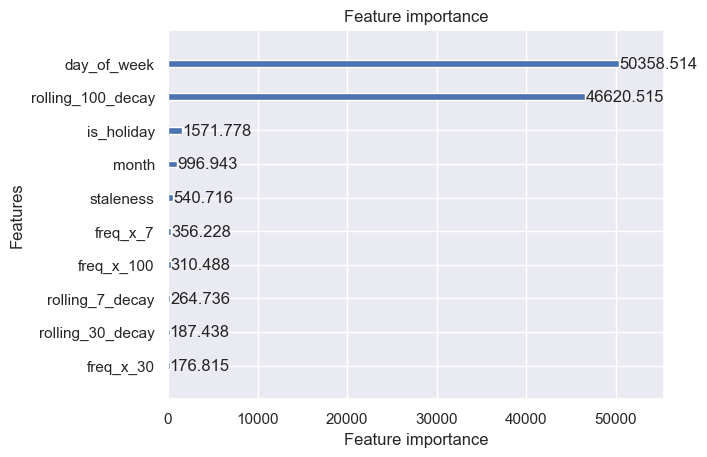

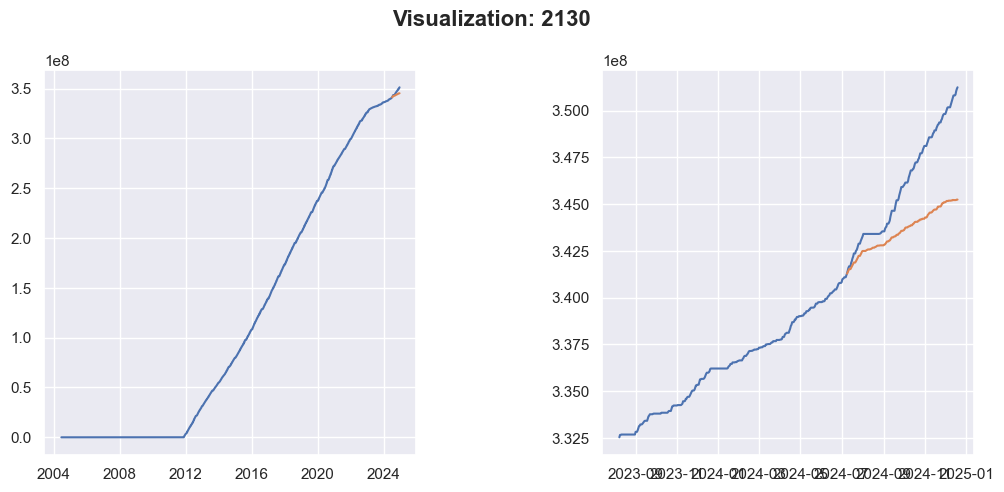

True

In [570]:
#MAIN.
IMPORTANT_DAYS = 1000
IMPORTANT_IDS = range(0,1,1) #predict the most important IDs, ranging from start to finish.
#submission_df = pd.read.csv("data/prediction_mapping.csv")

run(clean_df, IMPORTANT_DAYS, IMPORTANT_IDS, feature_columns, target)





     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      118440.0
1       30000.0
2           0.0
3           0.0
4           0.0
         ...   
159     61422.0
160     13760.0
161      6900.0
162         0.0
163         0.0
Name: daily_weight, Length: 164, dtype: float64


[I 2025-11-08 17:12:32,602] A new study created in memory with name: no-name-ec3b4a8d-e780-4868-992d-cf5b8903f218


12  days are marked as holidays
0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:12:32,802] Trial 0 finished with value: 143892.96067481968 and parameters: {'learning_rate': 0.025435283844024104, 'num_leaves': 73, 'min_data_in_leaf': 35, 'feature_fraction': 0.8649735117563566, 'bagging_fraction': 0.9468519187295353, 'bagging_freq': 4, 'reg_alpha': 0.7130399450881417, 'reg_lambda': 0.7626281813238536}. Best is trial 0 with value: 143892.96067481968.
[I 2025-11-08 17:12:32,879] Trial 1 finished with value: 106555.82103128245 and parameters: {'learning_rate': 0.01275323062649681, 'num_leaves': 57, 'min_data_in_leaf': 93, 'feature_fraction': 0.9307629017089272, 'bagging_fraction': 0.632396071210001, 'bagging_freq': 7, 'reg_alpha': 0.8496885730132403, 'reg_lambda': 0.8646538838022345}. Best is trial 1 with value: 106555.82103128245.
[I 2025-11-08 17:12:32,992] Trial 2 finished with value: 88405.38540865185 and parameters: {'learning_rate': 0.09432670878823735, 'num_leaves': 43, 'min_data_in_leaf': 62, 'feature_fraction': 0.593560155700825, 'bagging_frac

Best parameters: {'learning_rate': 0.019747823946999435, 'num_leaves': 78, 'min_data_in_leaf': 60, 'feature_fraction': 0.7132570110915264, 'bagging_fraction': 0.6635911626986837, 'bagging_freq': 7, 'reg_alpha': 0.6190917513949008, 'reg_lambda': 0.8763866163686802}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  12051.481959681409
baseline correct:  106700.15059039931
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  14425.42798445112
1


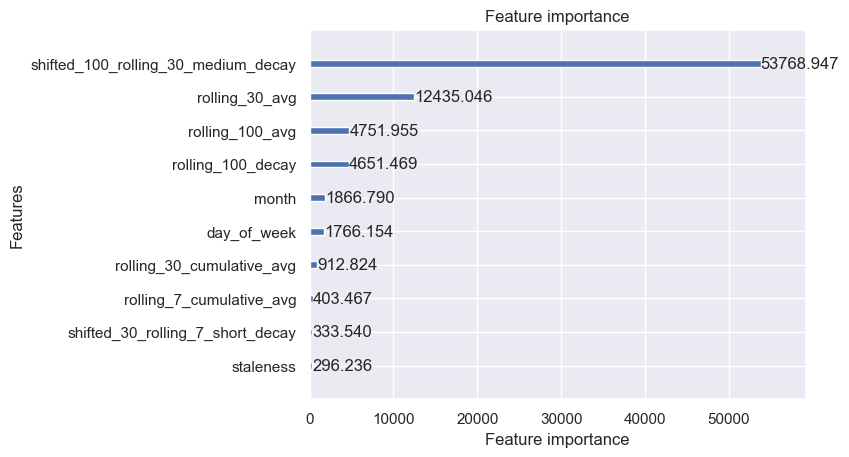

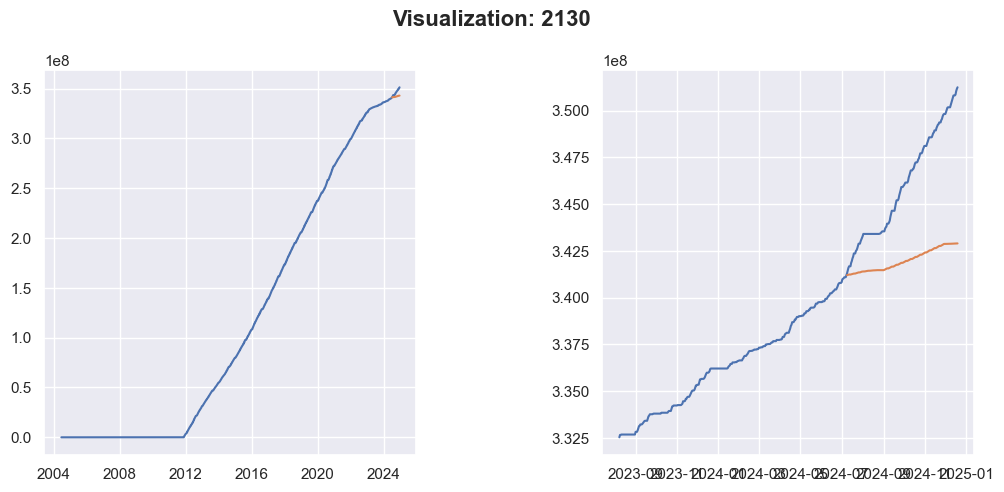

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0       22410.0
1        2428.0
2           0.0
3           0.0
4           0.0
         ...   
159     75819.0
160    127976.0
161     47160.0
162         0.0
163         0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:12:36,620] A new study created in memory with name: no-name-d705dddf-a069-45ac-8240-8ca84ba2adcb
[I 2025-11-08 17:12:36,655] Trial 0 finished with value: 663384.2739554835 and parameters: {'learning_rate': 0.09403728819641272, 'num_leaves': 56, 'min_data_in_leaf': 24, 'feature_fraction': 0.7352174078979716, 'bagging_fraction': 0.622855874398982, 'bagging_freq': 3, 'reg_alpha': 0.2623855392765675, 'reg_lambda': 0.4986939144445054}. Best is trial 0 with value: 663384.2739554835.
[I 2025-11-08 17:12:36,686] Trial 1 finished with value: 670530.6906961497 and parameters: {'learning_rate': 0.03941645934788122, 'num_leaves': 57, 'min_data_in_leaf': 24, 'feature_fraction': 0.9118049292583563, 'bagging_fraction': 0.5636244019733663, 'bagging_freq': 4, 'reg_alpha': 0.9494089633328825, 'reg_lambda': 0.7639782509477305}. Best is trial 0 with value: 663384.2739554835.
[I 2025-11-08 17:12:36,718] Trial 2 finished with value: 673982.8390243904 and parameters: {'learning_rate': 0.0613

0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:12:36,751] Trial 3 finished with value: 673982.8390243904 and parameters: {'learning_rate': 0.08000395742592066, 'num_leaves': 64, 'min_data_in_leaf': 81, 'feature_fraction': 0.7122501697053483, 'bagging_fraction': 0.963250285641239, 'bagging_freq': 5, 'reg_alpha': 0.5761473695111364, 'reg_lambda': 0.8072951893262698}. Best is trial 0 with value: 663384.2739554835.
[I 2025-11-08 17:12:36,786] Trial 4 finished with value: 673982.8390243904 and parameters: {'learning_rate': 0.07504402799297218, 'num_leaves': 30, 'min_data_in_leaf': 81, 'feature_fraction': 0.675796846048782, 'bagging_fraction': 0.561007899138193, 'bagging_freq': 5, 'reg_alpha': 0.003455186047607861, 'reg_lambda': 0.0856261838810729}. Best is trial 0 with value: 663384.2739554835.
[I 2025-11-08 17:12:36,820] Trial 5 finished with value: 673982.8390243904 and parameters: {'learning_rate': 0.07989337602274896, 'num_leaves': 81, 'min_data_in_leaf': 70, 'feature_fraction': 0.8376981923663136, 'bagging_fraction

Best parameters: {'learning_rate': 0.010678173450315211, 'num_leaves': 77, 'min_data_in_leaf': 11, 'feature_fraction': 0.9830855128910022, 'bagging_fraction': 0.5046439708331433, 'bagging_freq': 1, 'reg_alpha': 0.9872605527168903, 'reg_lambda': 0.6569165016732312}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  14425.42798445112
baseline correct:  71582.5551128422
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  12829.321948575494
1


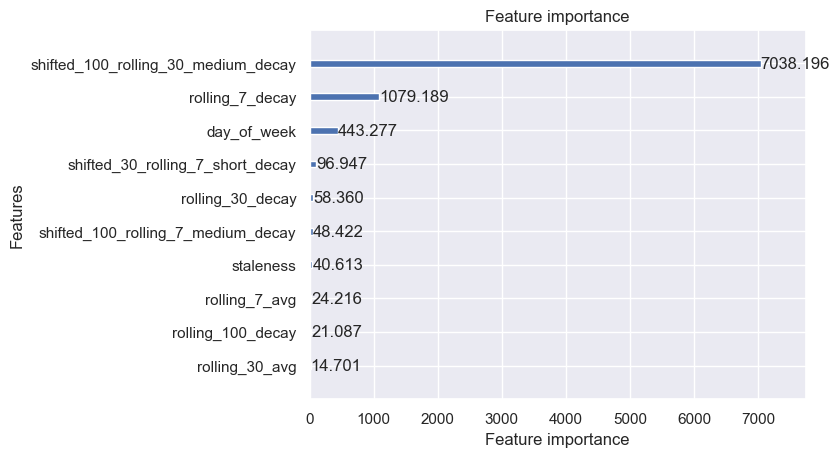

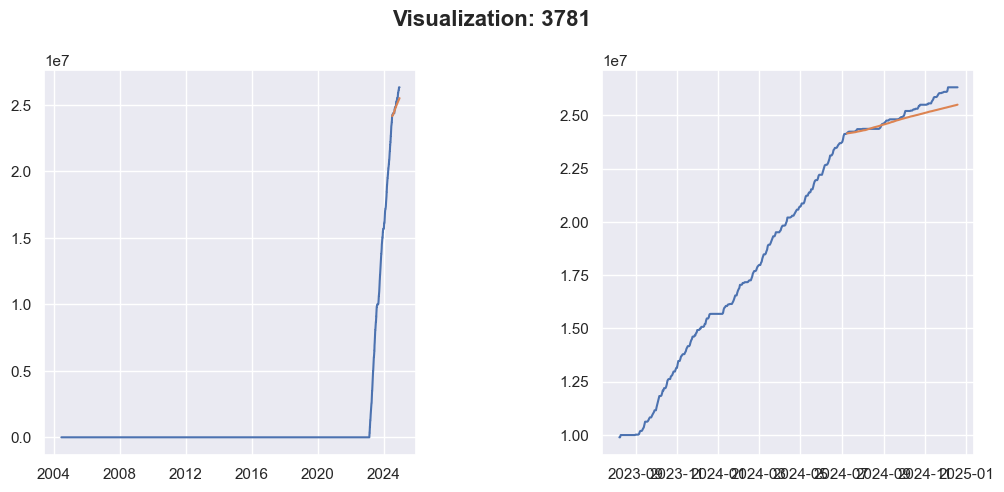

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    43300.0
160        0.0
161    46660.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:12:38,463] A new study created in memory with name: no-name-b02852f8-e8fb-47b7-ae3c-e5975daa1410
[I 2025-11-08 17:12:38,512] Trial 0 finished with value: 267163.0584665776 and parameters: {'learning_rate': 0.01007816726659049, 'num_leaves': 37, 'min_data_in_leaf': 69, 'feature_fraction': 0.5151858150748945, 'bagging_fraction': 0.5230677625184847, 'bagging_freq': 5, 'reg_alpha': 0.20128676663832012, 'reg_lambda': 0.41150317497169586}. Best is trial 0 with value: 267163.0584665776.


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:12:38,584] Trial 1 finished with value: 152011.55126411855 and parameters: {'learning_rate': 0.06024357987116559, 'num_leaves': 27, 'min_data_in_leaf': 64, 'feature_fraction': 0.6051220047635129, 'bagging_fraction': 0.9605020949012872, 'bagging_freq': 9, 'reg_alpha': 0.23821372984774025, 'reg_lambda': 0.4406956078994946}. Best is trial 1 with value: 152011.55126411855.
[I 2025-11-08 17:12:38,636] Trial 2 finished with value: 257940.13723460466 and parameters: {'learning_rate': 0.021262831031662925, 'num_leaves': 30, 'min_data_in_leaf': 68, 'feature_fraction': 0.8671913088571586, 'bagging_fraction': 0.5667380446171766, 'bagging_freq': 4, 'reg_alpha': 0.9715028634180976, 'reg_lambda': 0.11999520001920672}. Best is trial 1 with value: 152011.55126411855.
[I 2025-11-08 17:12:38,691] Trial 3 finished with value: 90873.86823925607 and parameters: {'learning_rate': 0.05707287304794647, 'num_leaves': 80, 'min_data_in_leaf': 83, 'feature_fraction': 0.6640812789365409, 'bagging_

Best parameters: {'learning_rate': 0.0932458753585233, 'num_leaves': 53, 'min_data_in_leaf': 35, 'feature_fraction': 0.9956698017518456, 'bagging_fraction': 0.5658291828005626, 'bagging_freq': 1, 'reg_alpha': 0.5367045335782936, 'reg_lambda': 0.2784408759017448}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  12829.321948575494
baseline correct:  187186.02443861088
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  11704.52651672292
1


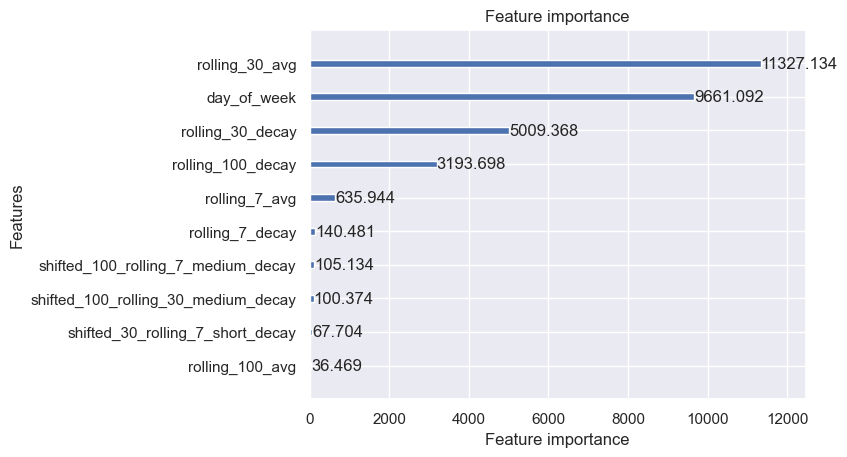

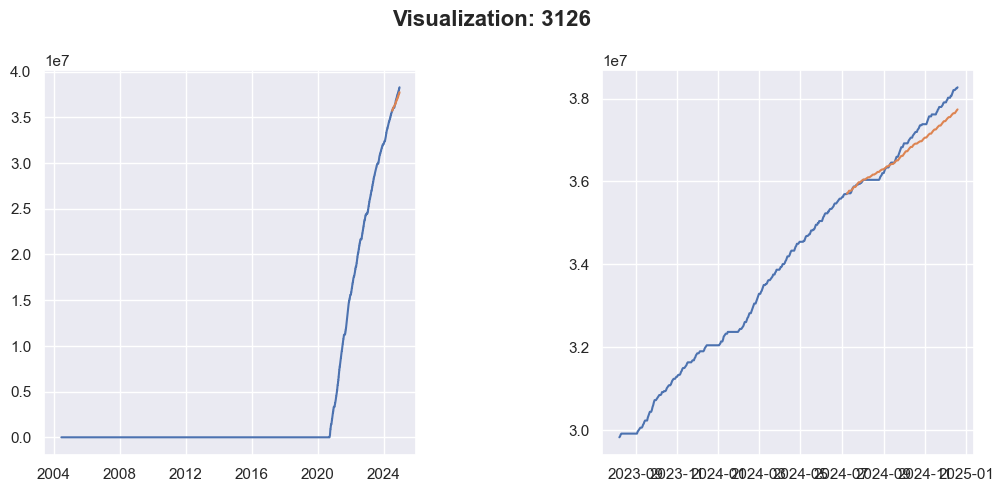

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      38228.0
1      57227.0
2          0.0
3          0.0
4          0.0
        ...   
159    99996.0
160    60346.0
161    68163.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:12:41,223] A new study created in memory with name: no-name-7ddc0efc-85fe-4adb-9af3-d822b7e90b06
[I 2025-11-08 17:12:41,249] Trial 0 finished with value: 431385.98292682937 and parameters: {'learning_rate': 0.05462488755431474, 'num_leaves': 98, 'min_data_in_leaf': 75, 'feature_fraction': 0.991303846712329, 'bagging_fraction': 0.8618025789126711, 'bagging_freq': 6, 'reg_alpha': 0.8284751362352201, 'reg_lambda': 0.6645559831434257}. Best is trial 0 with value: 431385.98292682937.
[I 2025-11-08 17:12:41,273] Trial 1 finished with value: 431385.98292682937 and parameters: {'learning_rate': 0.08930059930199671, 'num_leaves': 37, 'min_data_in_leaf': 54, 'feature_fraction': 0.5362532061238544, 'bagging_fraction': 0.575762786858437, 'bagging_freq': 1, 'reg_alpha': 0.18640107186870658, 'reg_lambda': 0.3231481072743754}. Best is trial 0 with value: 431385.98292682937.
[I 2025-11-08 17:12:41,300] Trial 2 finished with value: 431385.98292682937 and parameters: {'learning_rate': 0

split data: Check!


[I 2025-11-08 17:12:41,391] Trial 5 finished with value: 431385.98292682937 and parameters: {'learning_rate': 0.09422139184154768, 'num_leaves': 100, 'min_data_in_leaf': 65, 'feature_fraction': 0.9147635491550116, 'bagging_fraction': 0.5340178626168225, 'bagging_freq': 3, 'reg_alpha': 0.9665749670811729, 'reg_lambda': 0.08713480976779486}. Best is trial 0 with value: 431385.98292682937.
[I 2025-11-08 17:12:41,419] Trial 6 finished with value: 431385.98292682937 and parameters: {'learning_rate': 0.06854404016557646, 'num_leaves': 31, 'min_data_in_leaf': 90, 'feature_fraction': 0.9451870041867494, 'bagging_fraction': 0.8886139512342199, 'bagging_freq': 5, 'reg_alpha': 0.7345935419001488, 'reg_lambda': 0.4868370854098545}. Best is trial 0 with value: 431385.98292682937.
[I 2025-11-08 17:12:41,451] Trial 7 finished with value: 431385.98292682937 and parameters: {'learning_rate': 0.02103948342961294, 'num_leaves': 79, 'min_data_in_leaf': 18, 'feature_fraction': 0.6727174495007444, 'bagging_

Best parameters: {'learning_rate': 0.05462488755431474, 'num_leaves': 98, 'min_data_in_leaf': 75, 'feature_fraction': 0.991303846712329, 'bagging_fraction': 0.8618025789126711, 'bagging_freq': 6, 'reg_alpha': 0.8284751362352201, 'reg_lambda': 0.6645559831434257}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  11704.52651672292
baseline correct:  132630.94201536532
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  11234.481524143972
1


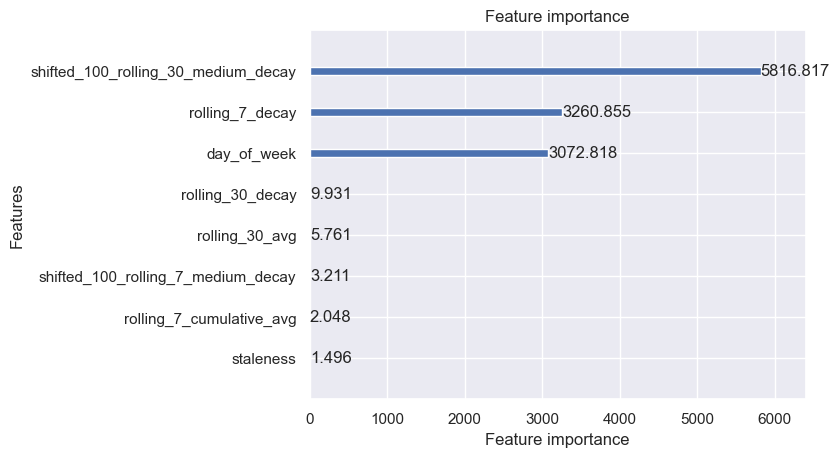

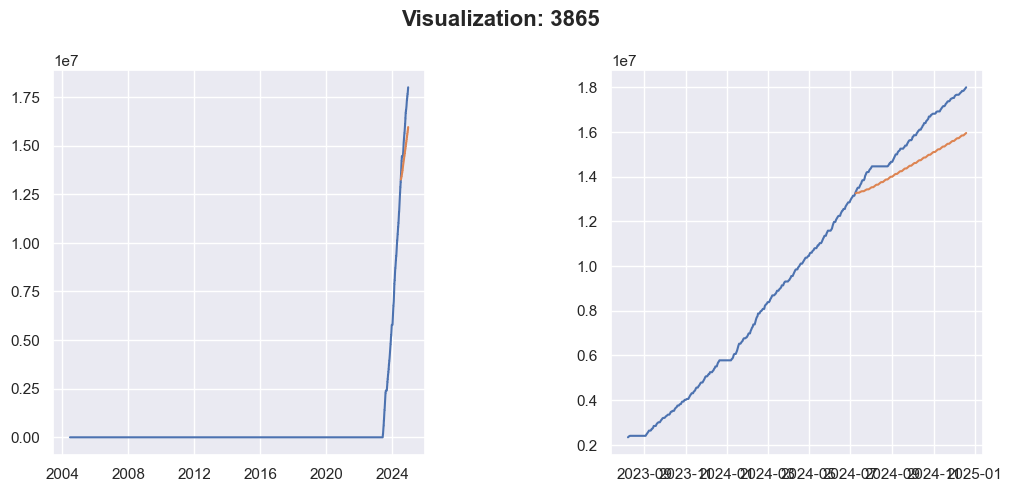

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
159    0.0
160    0.0
161    0.0
162    0.0
163    0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:12:42,932] A new study created in memory with name: no-name-69ff6b11-4208-48f7-a673-a0cc3a441c00


split data: Check!


[I 2025-11-08 17:12:43,177] Trial 0 finished with value: 66335.43708488252 and parameters: {'learning_rate': 0.05646097230699255, 'num_leaves': 86, 'min_data_in_leaf': 25, 'feature_fraction': 0.8208029450513872, 'bagging_fraction': 0.7015832737919707, 'bagging_freq': 1, 'reg_alpha': 0.17630908187293337, 'reg_lambda': 0.9654280584081733}. Best is trial 0 with value: 66335.43708488252.
[I 2025-11-08 17:12:43,277] Trial 1 finished with value: 145082.81740013591 and parameters: {'learning_rate': 0.013155632316266323, 'num_leaves': 77, 'min_data_in_leaf': 66, 'feature_fraction': 0.5761613090094961, 'bagging_fraction': 0.5494614048124509, 'bagging_freq': 3, 'reg_alpha': 0.6364240907431538, 'reg_lambda': 0.6015372895405016}. Best is trial 0 with value: 66335.43708488252.
[I 2025-11-08 17:12:43,394] Trial 2 finished with value: 69294.36408550182 and parameters: {'learning_rate': 0.09265489395306664, 'num_leaves': 41, 'min_data_in_leaf': 89, 'feature_fraction': 0.9580097091116315, 'bagging_frac

Best parameters: {'learning_rate': 0.05646097230699255, 'num_leaves': 86, 'min_data_in_leaf': 25, 'feature_fraction': 0.8208029450513872, 'bagging_fraction': 0.7015832737919707, 'bagging_freq': 1, 'reg_alpha': 0.17630908187293337, 'reg_lambda': 0.9654280584081733}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  11234.481524143972
baseline correct:  0.009822716807802665
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  11234.438867897723
1


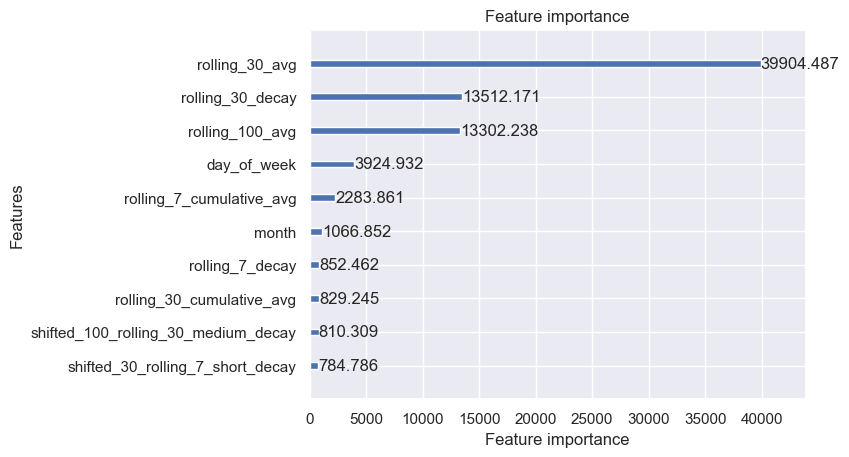

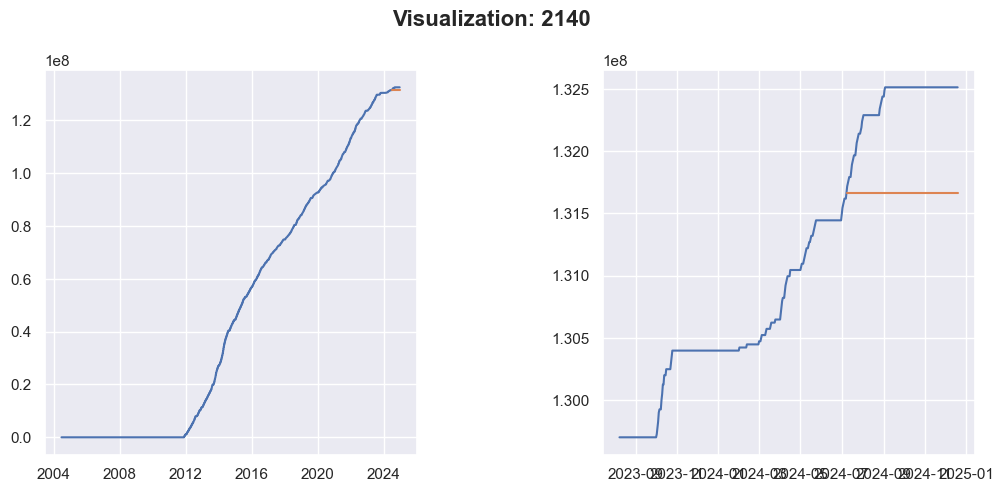

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    23640.0
160    48200.0
161    25040.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:12:47,367] A new study created in memory with name: no-name-b9a702a5-231d-4f5c-9fd4-d0636aa852ba
[I 2025-11-08 17:12:47,422] Trial 0 finished with value: 160679.68314024105 and parameters: {'learning_rate': 0.06237324267425692, 'num_leaves': 62, 'min_data_in_leaf': 87, 'feature_fraction': 0.7945632173781894, 'bagging_fraction': 0.7685273093818625, 'bagging_freq': 7, 'reg_alpha': 0.26389474389747913, 'reg_lambda': 0.9575352280975059}. Best is trial 0 with value: 160679.68314024105.
[I 2025-11-08 17:12:47,479] Trial 1 finished with value: 115992.08212021059 and parameters: {'learning_rate': 0.033487423675812665, 'num_leaves': 52, 'min_data_in_leaf': 79, 'feature_fraction': 0.9138908333145419, 'bagging_fraction': 0.812731314716891, 'bagging_freq': 7, 'reg_alpha': 0.7296163648409622, 'reg_lambda': 0.5384450084391106}. Best is trial 1 with value: 115992.08212021059.


split data: Check!


[I 2025-11-08 17:12:47,557] Trial 2 finished with value: 121616.00546818928 and parameters: {'learning_rate': 0.03296673932629795, 'num_leaves': 56, 'min_data_in_leaf': 32, 'feature_fraction': 0.955451794663015, 'bagging_fraction': 0.7416676255277936, 'bagging_freq': 7, 'reg_alpha': 0.9614833362083743, 'reg_lambda': 0.5220859854190673}. Best is trial 1 with value: 115992.08212021059.
[I 2025-11-08 17:12:47,619] Trial 3 finished with value: 159148.53658536586 and parameters: {'learning_rate': 0.023172374380999193, 'num_leaves': 76, 'min_data_in_leaf': 92, 'feature_fraction': 0.8438152037213619, 'bagging_fraction': 0.9838879261622635, 'bagging_freq': 7, 'reg_alpha': 0.6671991249749649, 'reg_lambda': 0.7239926140198073}. Best is trial 1 with value: 115992.08212021059.
[I 2025-11-08 17:12:47,675] Trial 4 finished with value: 157222.69988464456 and parameters: {'learning_rate': 0.03845163085284169, 'num_leaves': 37, 'min_data_in_leaf': 75, 'feature_fraction': 0.8585379155998013, 'bagging_fr

Best parameters: {'learning_rate': 0.09904904906670911, 'num_leaves': 41, 'min_data_in_leaf': 43, 'feature_fraction': 0.6899195268929252, 'bagging_fraction': 0.8647275337337985, 'bagging_freq': 9, 'reg_alpha': 0.47083043879148634, 'reg_lambda': 0.29633616837847154}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  11234.438867897723
baseline correct:  57597.78744099174
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10854.340944934047
1


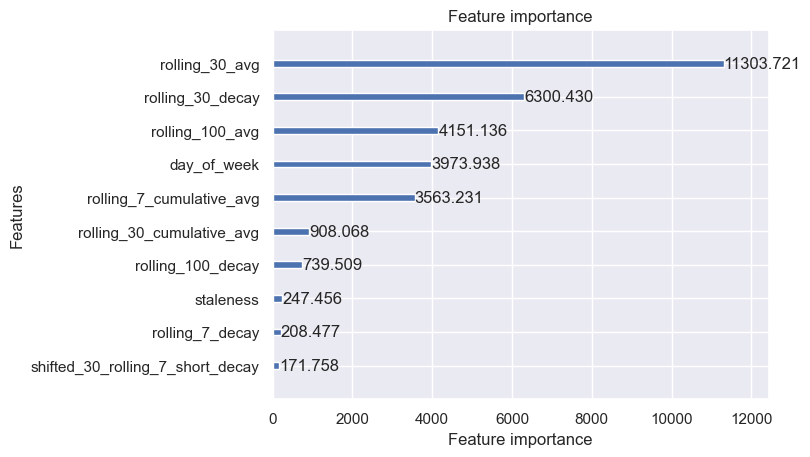

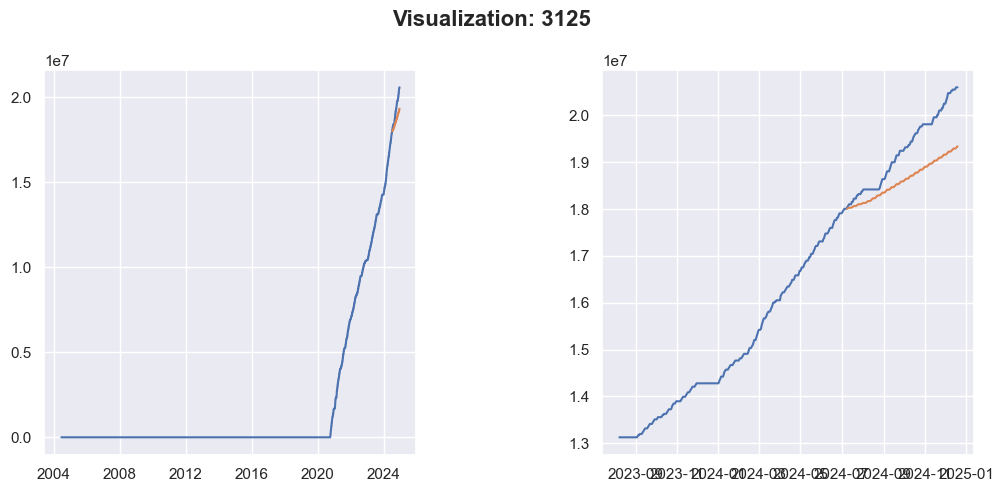

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159        0.0
160    48400.0
161    48160.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:12:49,950] A new study created in memory with name: no-name-5a13f336-efc3-422e-8784-71b541002b1c
[I 2025-11-08 17:12:50,045] Trial 0 finished with value: 319786.0943727894 and parameters: {'learning_rate': 0.077842260428553, 'num_leaves': 73, 'min_data_in_leaf': 64, 'feature_fraction': 0.5397671698294182, 'bagging_fraction': 0.6315155873852063, 'bagging_freq': 7, 'reg_alpha': 0.40873947899086804, 'reg_lambda': 0.5005049568315084}. Best is trial 0 with value: 319786.0943727894.


split data: Check!


[I 2025-11-08 17:12:50,152] Trial 1 finished with value: 79818.54327295796 and parameters: {'learning_rate': 0.07873375206914264, 'num_leaves': 29, 'min_data_in_leaf': 36, 'feature_fraction': 0.8924993205148545, 'bagging_fraction': 0.7237647261065783, 'bagging_freq': 7, 'reg_alpha': 0.09440609489175633, 'reg_lambda': 0.9911090790021287}. Best is trial 1 with value: 79818.54327295796.
[I 2025-11-08 17:12:50,289] Trial 2 finished with value: 139003.90568668858 and parameters: {'learning_rate': 0.01606015516237693, 'num_leaves': 44, 'min_data_in_leaf': 11, 'feature_fraction': 0.5504601204156858, 'bagging_fraction': 0.7781405728361644, 'bagging_freq': 8, 'reg_alpha': 0.4410876214300782, 'reg_lambda': 0.5721034784038239}. Best is trial 1 with value: 79818.54327295796.
[I 2025-11-08 17:12:50,334] Trial 3 finished with value: 171535.56098401215 and parameters: {'learning_rate': 0.08110735102781438, 'num_leaves': 64, 'min_data_in_leaf': 90, 'feature_fraction': 0.5961237279391843, 'bagging_frac

Best parameters: {'learning_rate': 0.06498162235603466, 'num_leaves': 38, 'min_data_in_leaf': 53, 'feature_fraction': 0.6851978374942023, 'bagging_fraction': 0.6378912432773729, 'bagging_freq': 1, 'reg_alpha': 0.1825436647179334, 'reg_lambda': 0.41617357239672403}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10854.340944934047
baseline correct:  -1329.3501088496741
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10831.187963235618
1


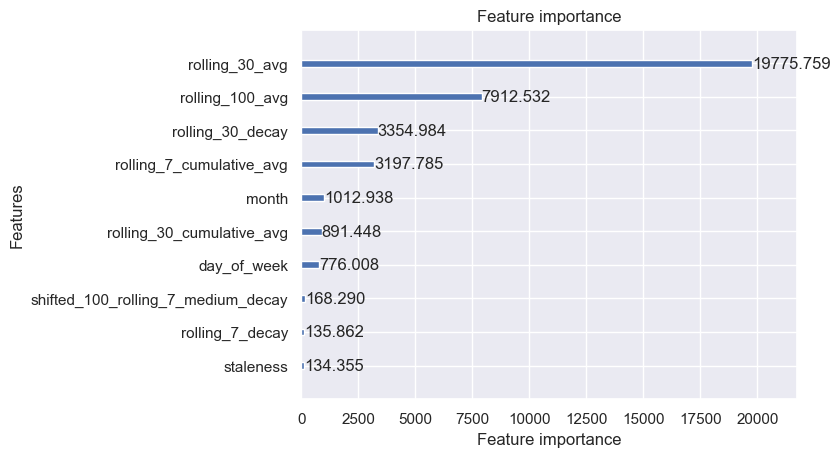

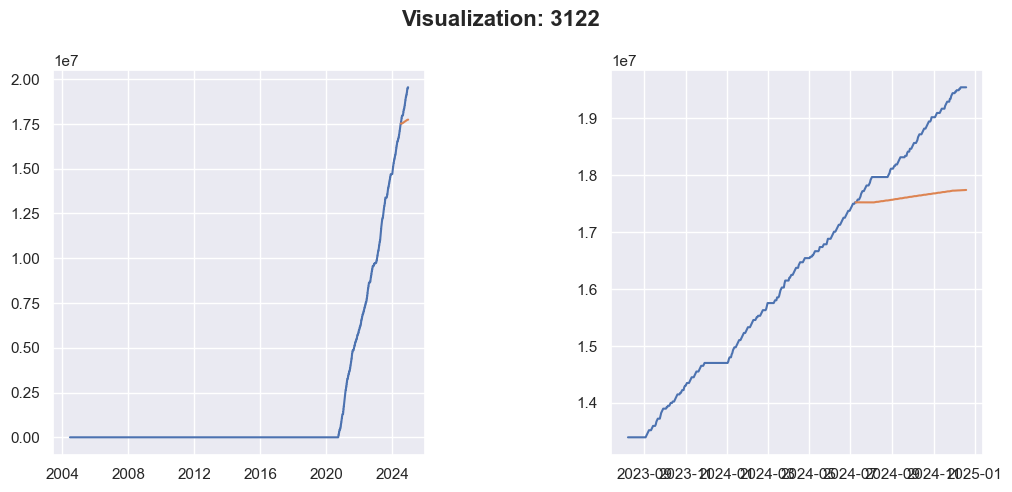

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    25260.0
160    25400.0
161    25200.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:12:53,318] A new study created in memory with name: no-name-62aefff5-146f-4fb9-afb7-e1bf48399bfc
[I 2025-11-08 17:12:53,361] Trial 0 finished with value: 144044.63414634147 and parameters: {'learning_rate': 0.05028120081837452, 'num_leaves': 79, 'min_data_in_leaf': 83, 'feature_fraction': 0.5345484871105597, 'bagging_fraction': 0.9093027452057154, 'bagging_freq': 8, 'reg_alpha': 0.47620969116561873, 'reg_lambda': 0.8741199864984792}. Best is trial 0 with value: 144044.63414634147.
[I 2025-11-08 17:12:53,409] Trial 1 finished with value: 138665.42949293312 and parameters: {'learning_rate': 0.08937170506314139, 'num_leaves': 36, 'min_data_in_leaf': 40, 'feature_fraction': 0.5696473221915979, 'bagging_fraction': 0.6481891243063429, 'bagging_freq': 5, 'reg_alpha': 0.06742045582714018, 'reg_lambda': 0.6231228342185691}. Best is trial 1 with value: 138665.42949293312.


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:12:53,473] Trial 2 finished with value: 137291.16193150793 and parameters: {'learning_rate': 0.07941806828743406, 'num_leaves': 85, 'min_data_in_leaf': 26, 'feature_fraction': 0.6459970535750088, 'bagging_fraction': 0.9238306694536724, 'bagging_freq': 10, 'reg_alpha': 0.4942501159031337, 'reg_lambda': 0.8088200508822488}. Best is trial 2 with value: 137291.16193150793.
[I 2025-11-08 17:12:53,520] Trial 3 finished with value: 114883.85430308808 and parameters: {'learning_rate': 0.07216664584856211, 'num_leaves': 85, 'min_data_in_leaf': 40, 'feature_fraction': 0.7564192798180341, 'bagging_fraction': 0.6546662060514365, 'bagging_freq': 9, 'reg_alpha': 0.3044335552163986, 'reg_lambda': 0.37343084131750826}. Best is trial 3 with value: 114883.85430308808.
[I 2025-11-08 17:12:53,556] Trial 4 finished with value: 142781.4789481746 and parameters: {'learning_rate': 0.03983373246122763, 'num_leaves': 86, 'min_data_in_leaf': 59, 'feature_fraction': 0.6868089056689481, 'bagging_f

Best parameters: {'learning_rate': 0.07216664584856211, 'num_leaves': 85, 'min_data_in_leaf': 40, 'feature_fraction': 0.7564192798180341, 'bagging_fraction': 0.6546662060514365, 'bagging_freq': 9, 'reg_alpha': 0.3044335552163986, 'reg_lambda': 0.37343084131750826}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10831.187963235618
baseline correct:  147741.21263829505
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10698.562133569654
1


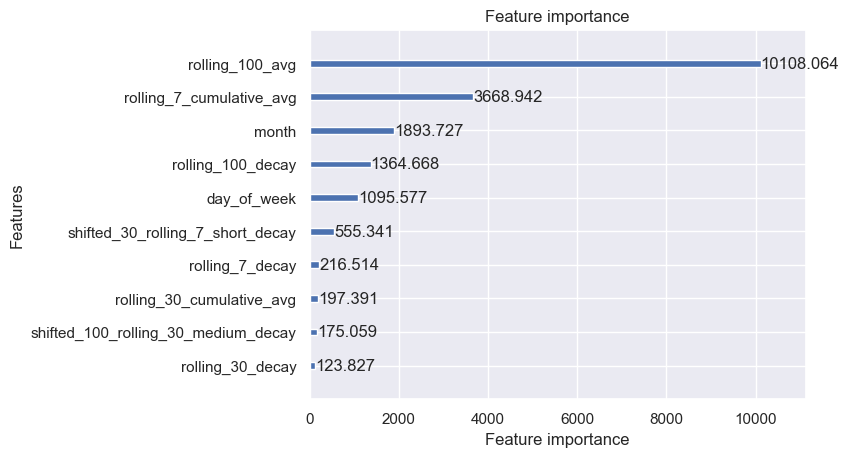

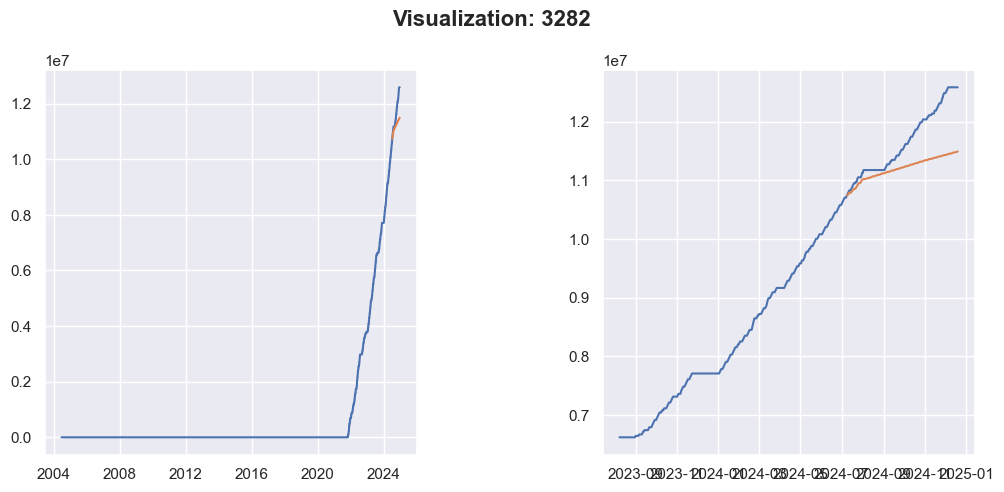

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:12:55,884] A new study created in memory with name: no-name-9d5309c3-d247-471d-9ed7-d97d93e966b1
[I 2025-11-08 17:12:55,937] Trial 0 finished with value: 104152.37619397372 and parameters: {'learning_rate': 0.09414898746669546, 'num_leaves': 78, 'min_data_in_leaf': 46, 'feature_fraction': 0.8412237955323401, 'bagging_fraction': 0.6512284799878993, 'bagging_freq': 1, 'reg_alpha': 0.29931984516491683, 'reg_lambda': 0.9196135693230852}. Best is trial 0 with value: 104152.37619397372.


0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    25120.0
160    25960.0
161    50620.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:12:55,978] Trial 1 finished with value: 131037.29268292683 and parameters: {'learning_rate': 0.024870685036529238, 'num_leaves': 46, 'min_data_in_leaf': 87, 'feature_fraction': 0.6176739608759805, 'bagging_fraction': 0.5666861288124954, 'bagging_freq': 5, 'reg_alpha': 0.4052615250720405, 'reg_lambda': 0.49122936608586554}. Best is trial 0 with value: 104152.37619397372.
[I 2025-11-08 17:12:56,037] Trial 2 finished with value: 42245.11931597109 and parameters: {'learning_rate': 0.013516914689767092, 'num_leaves': 31, 'min_data_in_leaf': 51, 'feature_fraction': 0.8781353495384078, 'bagging_fraction': 0.9912453312061449, 'bagging_freq': 10, 'reg_alpha': 0.8368734067763316, 'reg_lambda': 0.3794576563116945}. Best is trial 2 with value: 42245.11931597109.
[I 2025-11-08 17:12:56,112] Trial 3 finished with value: 85199.70976511003 and parameters: {'learning_rate': 0.07150279951179811, 'num_leaves': 88, 'min_data_in_leaf': 25, 'feature_fraction': 0.8192109556656524, 'bagging_f

Best parameters: {'learning_rate': 0.013516914689767092, 'num_leaves': 31, 'min_data_in_leaf': 51, 'feature_fraction': 0.8781353495384078, 'bagging_fraction': 0.9912453312061449, 'bagging_freq': 10, 'reg_alpha': 0.8368734067763316, 'reg_lambda': 0.3794576563116945}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10698.562133569654
baseline correct:  64116.62045513768
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10916.871986023305
1


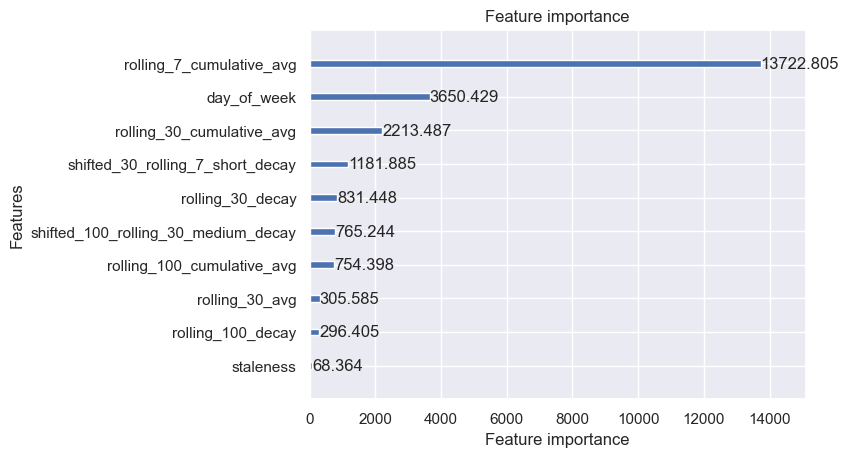

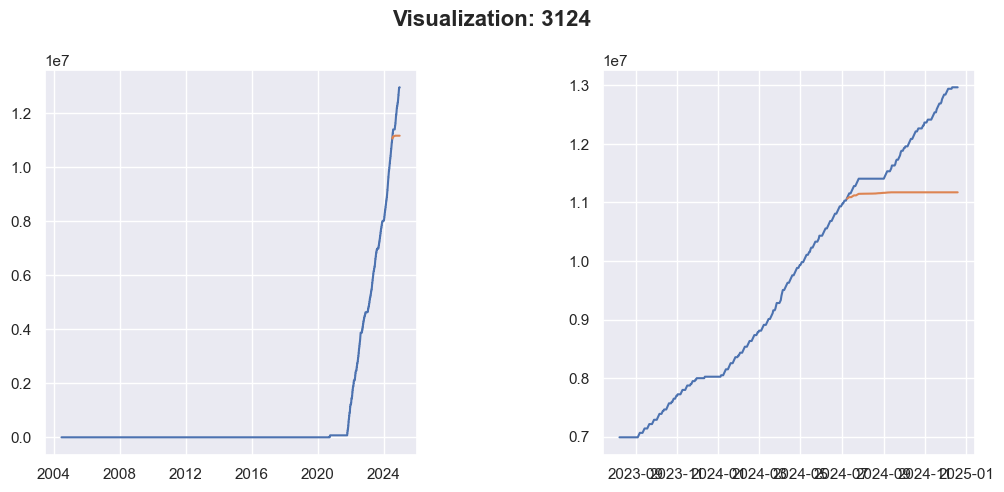

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
159    0.0
160    0.0
161    0.0
162    0.0
163    0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:12:58,143] A new study created in memory with name: no-name-217d36a8-c70d-40c7-b9f1-41807c6762eb
[I 2025-11-08 17:12:58,173] Trial 0 finished with value: 0.0 and parameters: {'learning_rate': 0.08395794197250649, 'num_leaves': 27, 'min_data_in_leaf': 67, 'feature_fraction': 0.6105918111695277, 'bagging_fraction': 0.5091053865380235, 'bagging_freq': 3, 'reg_alpha': 0.7121771545603766, 'reg_lambda': 0.22228284947596932}. Best is trial 0 with value: 0.0.
[I 2025-11-08 17:12:58,217] Trial 1 finished with value: 0.0 and parameters: {'learning_rate': 0.0660454633674344, 'num_leaves': 37, 'min_data_in_leaf': 33, 'feature_fraction': 0.9415502191281568, 'bagging_fraction': 0.8900033272788443, 'bagging_freq': 7, 'reg_alpha': 0.10645230138267481, 'reg_lambda': 0.04734678817641058}. Best is trial 0 with value: 0.0.
[I 2025-11-08 17:12:58,251] Trial 2 finished with value: 3025.981029201404 and parameters: {'learning_rate': 0.08948366420236818, 'num_leaves': 93, 'min_data_in_leaf': 

split data: Check!


[I 2025-11-08 17:12:58,338] Trial 4 finished with value: 29538.277022249735 and parameters: {'learning_rate': 0.04585344994130602, 'num_leaves': 76, 'min_data_in_leaf': 38, 'feature_fraction': 0.6546488446074692, 'bagging_fraction': 0.9830365477593944, 'bagging_freq': 9, 'reg_alpha': 0.1689573077416453, 'reg_lambda': 0.01288372820008099}. Best is trial 0 with value: 0.0.
[I 2025-11-08 17:12:58,373] Trial 5 finished with value: 0.0 and parameters: {'learning_rate': 0.02028085733366941, 'num_leaves': 59, 'min_data_in_leaf': 53, 'feature_fraction': 0.7440601630320958, 'bagging_fraction': 0.8067680222943041, 'bagging_freq': 6, 'reg_alpha': 0.6748880026044085, 'reg_lambda': 0.7875490730379405}. Best is trial 0 with value: 0.0.
[I 2025-11-08 17:12:58,414] Trial 6 finished with value: 67606.24535411008 and parameters: {'learning_rate': 0.09212685903704423, 'num_leaves': 53, 'min_data_in_leaf': 35, 'feature_fraction': 0.7627148058471795, 'bagging_fraction': 0.6754807219424372, 'bagging_freq': 

Best parameters: {'learning_rate': 0.08395794197250649, 'num_leaves': 27, 'min_data_in_leaf': 67, 'feature_fraction': 0.6105918111695277, 'bagging_fraction': 0.5091053865380235, 'bagging_freq': 3, 'reg_alpha': 0.7121771545603766, 'reg_lambda': 0.22228284947596932}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10916.871986023305
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10916.871986023305
1


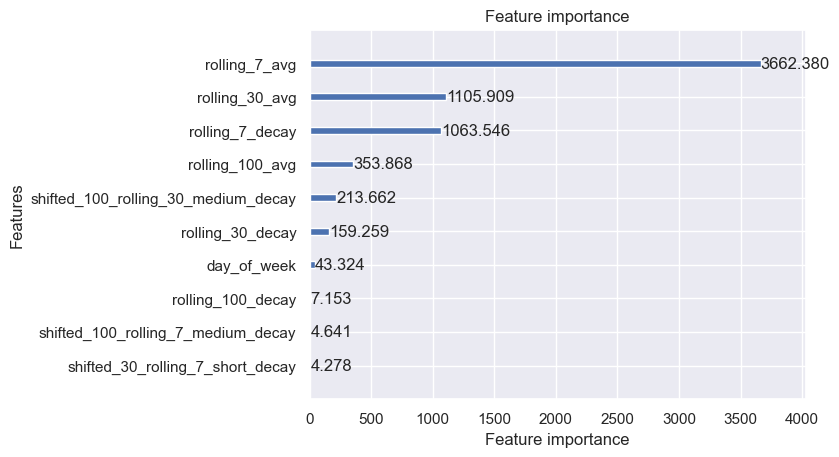

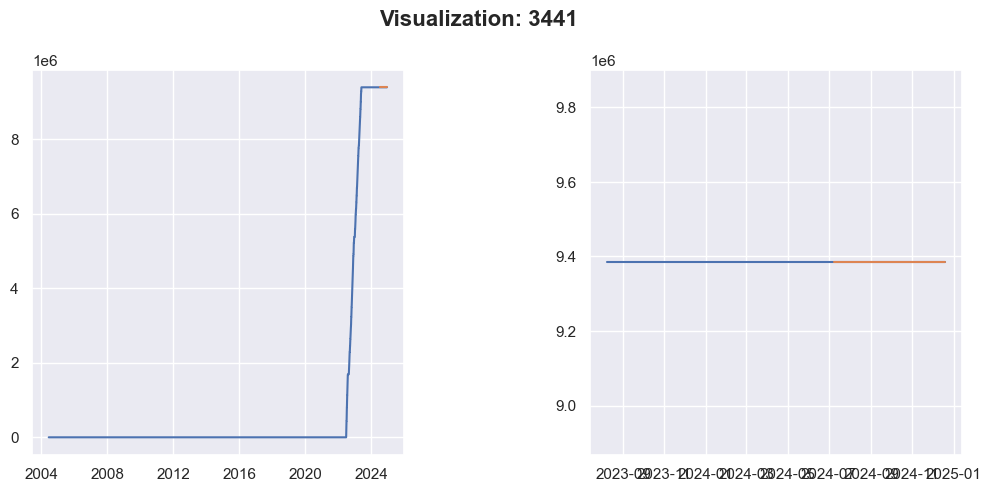

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    26580.0
160    24320.0
161        0.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:13:00,106] A new study created in memory with name: no-name-5784e217-d415-4bb3-b6aa-9387e26c77f4
[I 2025-11-08 17:13:00,149] Trial 0 finished with value: 102126.36585365854 and parameters: {'learning_rate': 0.030986299790104997, 'num_leaves': 86, 'min_data_in_leaf': 84, 'feature_fraction': 0.6815755928785833, 'bagging_fraction': 0.5209701246510428, 'bagging_freq': 5, 'reg_alpha': 0.6243590080158564, 'reg_lambda': 0.39961782194729933}. Best is trial 0 with value: 102126.36585365854.
[I 2025-11-08 17:13:00,202] Trial 1 finished with value: 102126.36585365854 and parameters: {'learning_rate': 0.08053770533629127, 'num_leaves': 80, 'min_data_in_leaf': 47, 'feature_fraction': 0.8683308630289711, 'bagging_fraction': 0.8038991996199416, 'bagging_freq': 5, 'reg_alpha': 0.7303371727496571, 'reg_lambda': 0.9567694118361701}. Best is trial 0 with value: 102126.36585365854.
[I 2025-11-08 17:13:00,243] Trial 2 finished with value: 102126.36585365854 and parameters: {'learning_rate'

split data: Check!


[I 2025-11-08 17:13:00,504] Trial 3 finished with value: 103022.04574676228 and parameters: {'learning_rate': 0.08759845962164826, 'num_leaves': 57, 'min_data_in_leaf': 25, 'feature_fraction': 0.6809466237944751, 'bagging_fraction': 0.5850927987923547, 'bagging_freq': 5, 'reg_alpha': 0.13495069461694575, 'reg_lambda': 0.34343607161114065}. Best is trial 0 with value: 102126.36585365854.
[I 2025-11-08 17:13:00,654] Trial 4 finished with value: 99699.76922370397 and parameters: {'learning_rate': 0.057560248838651046, 'num_leaves': 91, 'min_data_in_leaf': 15, 'feature_fraction': 0.54886129134153, 'bagging_fraction': 0.8981588716090262, 'bagging_freq': 1, 'reg_alpha': 0.5901848467967661, 'reg_lambda': 0.15939242290940314}. Best is trial 4 with value: 99699.76922370397.
[I 2025-11-08 17:13:00,700] Trial 5 finished with value: 102126.36585365854 and parameters: {'learning_rate': 0.010902868354870504, 'num_leaves': 77, 'min_data_in_leaf': 44, 'feature_fraction': 0.5027578245101929, 'bagging_f

Best parameters: {'learning_rate': 0.06829221895762615, 'num_leaves': 60, 'min_data_in_leaf': 10, 'feature_fraction': 0.5052767474395808, 'bagging_fraction': 0.9718580580727297, 'bagging_freq': 1, 'reg_alpha': 0.3922417807559327, 'reg_lambda': 0.07240185739440345}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10916.871986023305
baseline correct:  22186.980915796794
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10902.75358621253
1


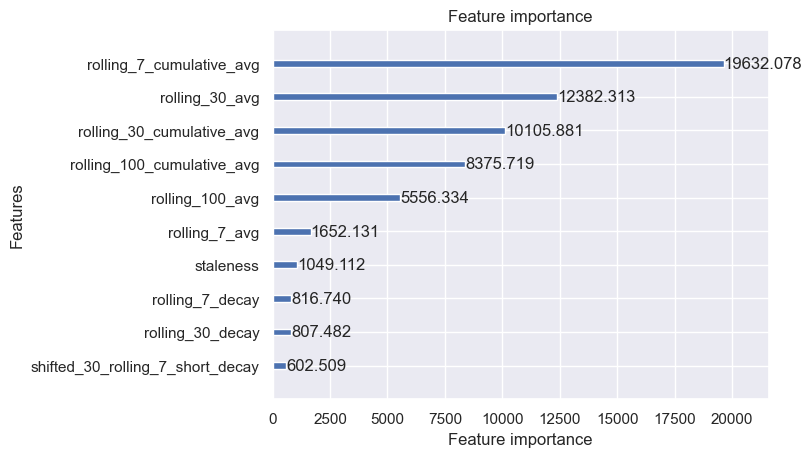

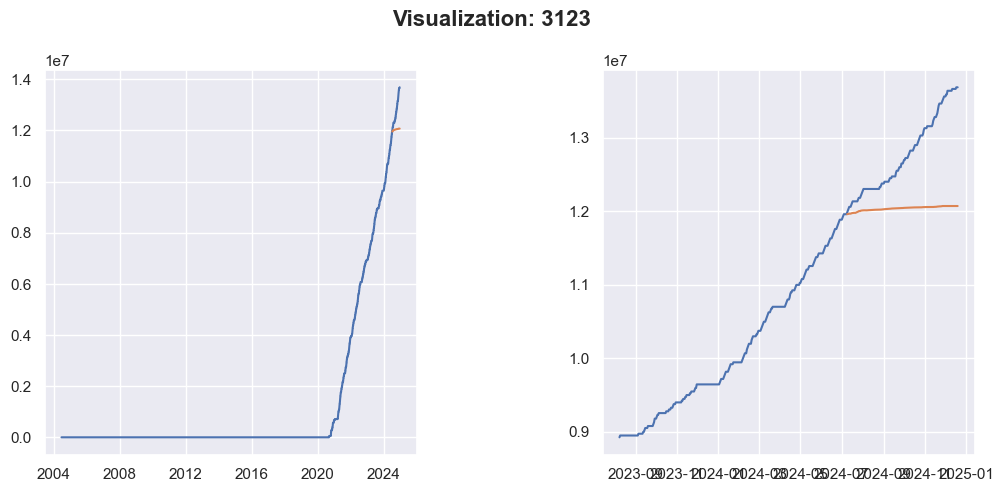

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
159    0.0
160    0.0
161    0.0
162    0.0
163    0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:13:03,287] A new study created in memory with name: no-name-3aec2cb5-c316-4fb4-873a-cff50497f95d


split data: Check!


[I 2025-11-08 17:13:03,440] Trial 0 finished with value: 0.0 and parameters: {'learning_rate': 0.08252591032636812, 'num_leaves': 32, 'min_data_in_leaf': 74, 'feature_fraction': 0.9580994360954891, 'bagging_fraction': 0.9648356130362216, 'bagging_freq': 3, 'reg_alpha': 0.7226084902362581, 'reg_lambda': 0.09094444192437467}. Best is trial 0 with value: 0.0.
[I 2025-11-08 17:13:03,603] Trial 1 finished with value: 0.0 and parameters: {'learning_rate': 0.07517039409890493, 'num_leaves': 34, 'min_data_in_leaf': 38, 'feature_fraction': 0.9698771568573972, 'bagging_fraction': 0.6080928239261663, 'bagging_freq': 6, 'reg_alpha': 0.34053068217894744, 'reg_lambda': 0.2650571530760274}. Best is trial 0 with value: 0.0.
[I 2025-11-08 17:13:03,751] Trial 2 finished with value: 0.0 and parameters: {'learning_rate': 0.04437233582078828, 'num_leaves': 69, 'min_data_in_leaf': 84, 'feature_fraction': 0.6787769710607643, 'bagging_fraction': 0.978542932587678, 'bagging_freq': 4, 'reg_alpha': 0.63787523295

Best parameters: {'learning_rate': 0.08252591032636812, 'num_leaves': 32, 'min_data_in_leaf': 74, 'feature_fraction': 0.9580994360954891, 'bagging_fraction': 0.9648356130362216, 'bagging_freq': 3, 'reg_alpha': 0.7226084902362581, 'reg_lambda': 0.09094444192437467}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10902.75358621253
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10902.75358621253
1


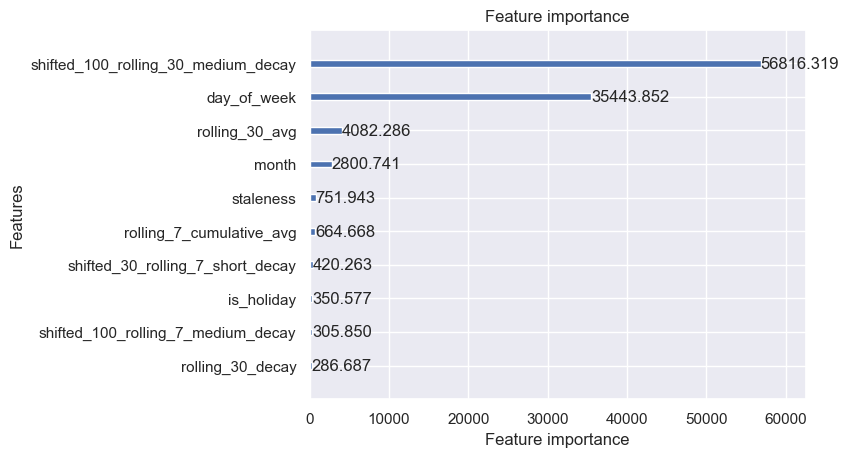

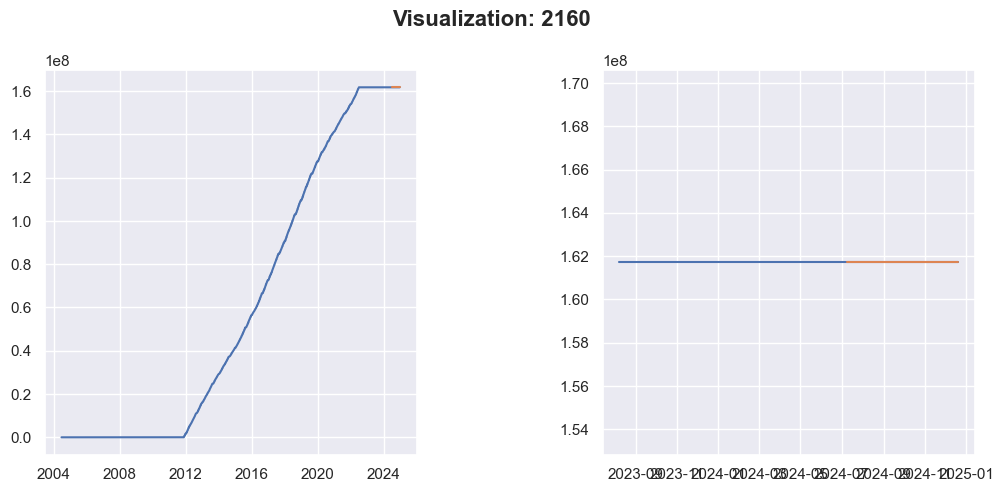

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1       9032.0
2          0.0
3          0.0
4          0.0
        ...   
159    20600.0
160        0.0
161        0.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:13:07,612] A new study created in memory with name: no-name-e874a83c-6ce1-47d9-9641-7ade4ba2a813
[I 2025-11-08 17:13:07,709] Trial 0 finished with value: 41481.76360086706 and parameters: {'learning_rate': 0.018848598765750124, 'num_leaves': 49, 'min_data_in_leaf': 62, 'feature_fraction': 0.5190607095681947, 'bagging_fraction': 0.575915583559012, 'bagging_freq': 7, 'reg_alpha': 0.5670743381256196, 'reg_lambda': 0.6705886341176176}. Best is trial 0 with value: 41481.76360086706.


split data: Check!


[I 2025-11-08 17:13:07,828] Trial 1 finished with value: 41324.50186141652 and parameters: {'learning_rate': 0.05388362455032686, 'num_leaves': 52, 'min_data_in_leaf': 48, 'feature_fraction': 0.5231905720525274, 'bagging_fraction': 0.8348825322149522, 'bagging_freq': 9, 'reg_alpha': 0.9867911130074194, 'reg_lambda': 0.19095608464901015}. Best is trial 1 with value: 41324.50186141652.
[I 2025-11-08 17:13:07,920] Trial 2 finished with value: 41406.78982737896 and parameters: {'learning_rate': 0.05784302146122864, 'num_leaves': 58, 'min_data_in_leaf': 77, 'feature_fraction': 0.7685515111314731, 'bagging_fraction': 0.5926951074352753, 'bagging_freq': 10, 'reg_alpha': 0.7733293767267299, 'reg_lambda': 0.2891160822588775}. Best is trial 1 with value: 41324.50186141652.
[I 2025-11-08 17:13:08,134] Trial 3 finished with value: 40790.10847166755 and parameters: {'learning_rate': 0.09942125406800366, 'num_leaves': 99, 'min_data_in_leaf': 34, 'feature_fraction': 0.9635731672265393, 'bagging_fract

Best parameters: {'learning_rate': 0.0871642000679271, 'num_leaves': 73, 'min_data_in_leaf': 11, 'feature_fraction': 0.715637178072852, 'bagging_fraction': 0.9204352561832752, 'bagging_freq': 6, 'reg_alpha': 0.8663289598865698, 'reg_lambda': 0.5414678022789395}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10902.75358621253
baseline correct:  150.90687435138824
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10907.995271938771
1


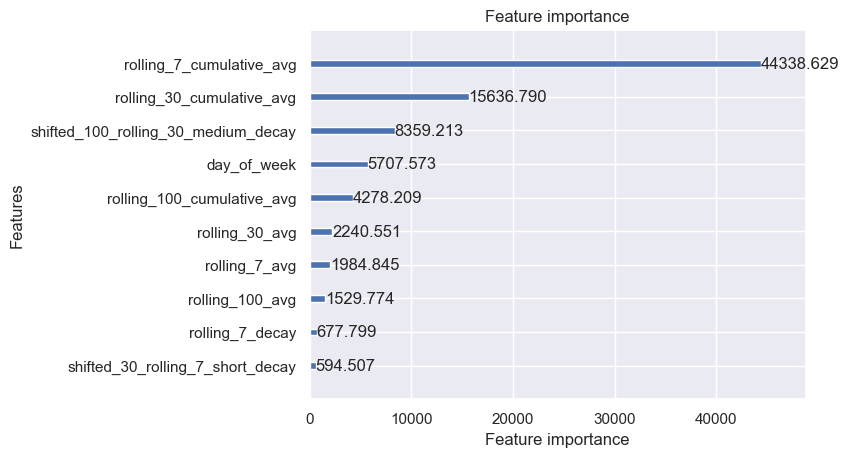

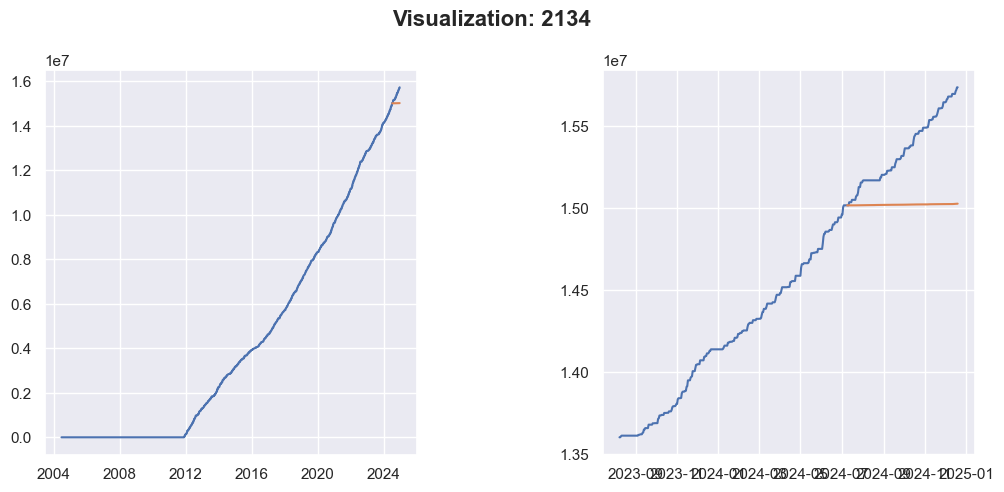

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0        520.0
1      16269.0
2          0.0
3          0.0
4          0.0
        ...   
159     3730.0
160     3320.0
161    19848.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:13:12,284] A new study created in memory with name: no-name-28e0d16d-218e-496a-b1bc-3e9e0295080b


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:12,404] Trial 0 finished with value: 47627.43193481575 and parameters: {'learning_rate': 0.016447393956534405, 'num_leaves': 31, 'min_data_in_leaf': 52, 'feature_fraction': 0.617036585876294, 'bagging_fraction': 0.5664883044340941, 'bagging_freq': 8, 'reg_alpha': 0.25612722657005904, 'reg_lambda': 0.2629658670695615}. Best is trial 0 with value: 47627.43193481575.
[I 2025-11-08 17:13:12,516] Trial 1 finished with value: 42705.27941738716 and parameters: {'learning_rate': 0.08331276741589706, 'num_leaves': 94, 'min_data_in_leaf': 74, 'feature_fraction': 0.9569062387443799, 'bagging_fraction': 0.6064141365576721, 'bagging_freq': 9, 'reg_alpha': 0.6761532669222753, 'reg_lambda': 0.9969227644350425}. Best is trial 1 with value: 42705.27941738716.
[I 2025-11-08 17:13:12,746] Trial 2 finished with value: 42773.18364290723 and parameters: {'learning_rate': 0.04360655859284252, 'num_leaves': 70, 'min_data_in_leaf': 52, 'feature_fraction': 0.9686619613000989, 'bagging_fracti

Best parameters: {'learning_rate': 0.09726881557621657, 'num_leaves': 88, 'min_data_in_leaf': 13, 'feature_fraction': 0.9921812152481586, 'bagging_fraction': 0.8169704245245767, 'bagging_freq': 5, 'reg_alpha': 0.5121984394016069, 'reg_lambda': 0.9013988227142039}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10907.995271938771
baseline correct:  12177.450028422718
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10885.309350356347
1


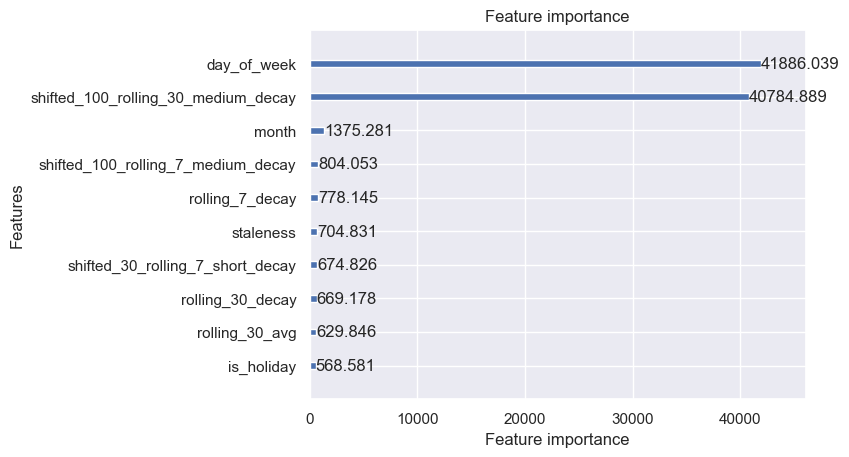

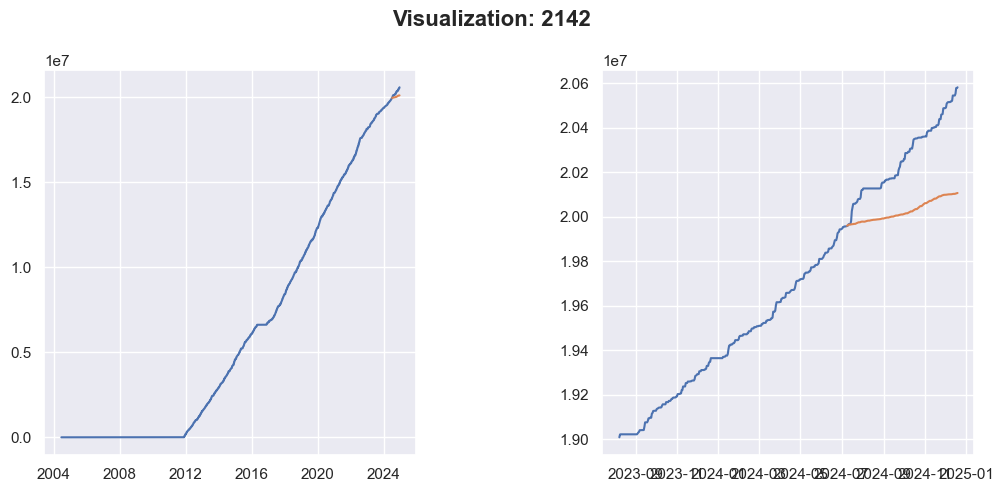

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    24960.0
160        0.0
161        0.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:19,130] A new study created in memory with name: no-name-6c613915-1e90-4c23-94da-de02726b487b
[I 2025-11-08 17:13:19,206] Trial 0 finished with value: 49580.30487804878 and parameters: {'learning_rate': 0.04781616856256666, 'num_leaves': 60, 'min_data_in_leaf': 60, 'feature_fraction': 0.8896610942331348, 'bagging_fraction': 0.6358513989500967, 'bagging_freq': 6, 'reg_alpha': 0.6474580679065285, 'reg_lambda': 0.8906426783979242}. Best is trial 0 with value: 49580.30487804878.
[I 2025-11-08 17:13:19,261] Trial 1 finished with value: 49580.30487804878 and parameters: {'learning_rate': 0.07349037570382096, 'num_leaves': 38, 'min_data_in_leaf': 53, 'feature_fraction': 0.6553042034037377, 'bagging_fraction': 0.8256269581234439, 'bagging_freq': 8, 'reg_alpha': 0.6631639621874785, 'reg_lambda': 0.5748521323630891}. Best is trial 0 with value: 49580.30487804878.
[I 2025-11-08 17:13:19,358] Trial 2 finished with value: 49580.30487804878 and parameters: {'learning_rate': 0.019

Best parameters: {'learning_rate': 0.04781616856256666, 'num_leaves': 60, 'min_data_in_leaf': 60, 'feature_fraction': 0.8896610942331348, 'bagging_fraction': 0.6358513989500967, 'bagging_freq': 6, 'reg_alpha': 0.6474580679065285, 'reg_lambda': 0.8906426783979242}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10885.309350356347
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10885.309350356347
1


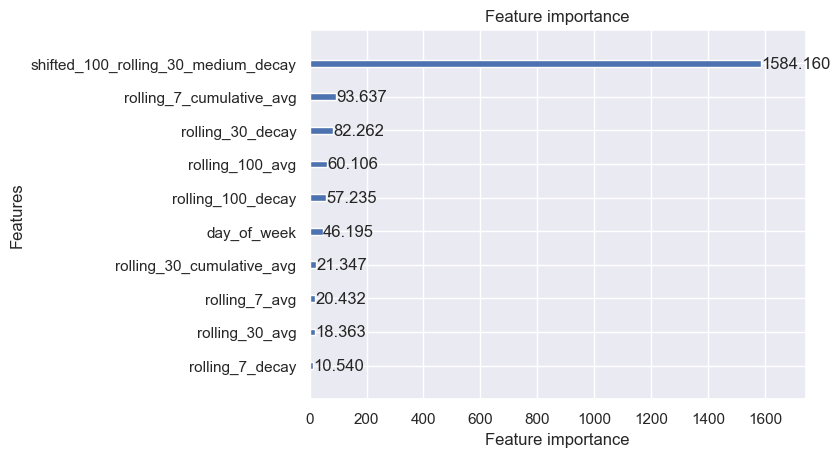

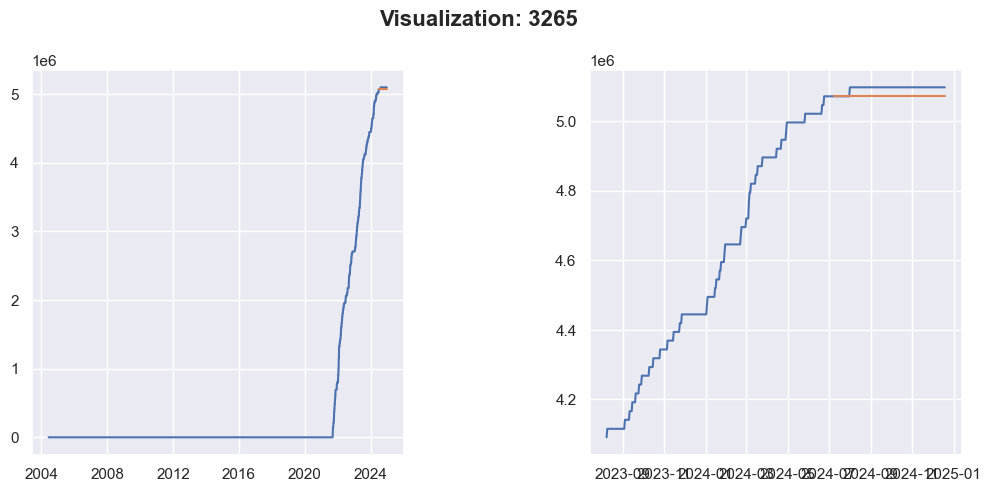

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays


[I 2025-11-08 17:13:22,857] A new study created in memory with name: no-name-da99fc93-ebe6-4619-84d3-db200f562657
[I 2025-11-08 17:13:22,892] Trial 0 finished with value: 26003.975609756097 and parameters: {'learning_rate': 0.08308667865143514, 'num_leaves': 52, 'min_data_in_leaf': 48, 'feature_fraction': 0.8598454142388516, 'bagging_fraction': 0.5667725788229896, 'bagging_freq': 4, 'reg_alpha': 0.460805761437998, 'reg_lambda': 0.28264953918524327}. Best is trial 0 with value: 26003.975609756097.


0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
        ...   
159    13840.0
160        0.0
161    24180.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:22,937] Trial 1 finished with value: 26003.975609756097 and parameters: {'learning_rate': 0.027894290019064058, 'num_leaves': 35, 'min_data_in_leaf': 21, 'feature_fraction': 0.5532110532337313, 'bagging_fraction': 0.5773905213447095, 'bagging_freq': 4, 'reg_alpha': 0.5338579768463295, 'reg_lambda': 0.24158327623141784}. Best is trial 0 with value: 26003.975609756097.
[I 2025-11-08 17:13:22,977] Trial 2 finished with value: 26003.975609756097 and parameters: {'learning_rate': 0.074496626714261, 'num_leaves': 96, 'min_data_in_leaf': 57, 'feature_fraction': 0.6490017386021927, 'bagging_fraction': 0.7536862853602401, 'bagging_freq': 2, 'reg_alpha': 0.4656425309826693, 'reg_lambda': 0.203149896270982}. Best is trial 0 with value: 26003.975609756097.
[I 2025-11-08 17:13:23,023] Trial 3 finished with value: 26003.975609756097 and parameters: {'learning_rate': 0.06571863101038335, 'num_leaves': 62, 'min_data_in_leaf': 22, 'feature_fraction': 0.5212560109174427, 'bagging_fra

Best parameters: {'learning_rate': 0.08308667865143514, 'num_leaves': 52, 'min_data_in_leaf': 48, 'feature_fraction': 0.8598454142388516, 'bagging_fraction': 0.5667725788229896, 'bagging_freq': 4, 'reg_alpha': 0.460805761437998, 'reg_lambda': 0.28264953918524327}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10885.309350356347
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10885.309350356347
1


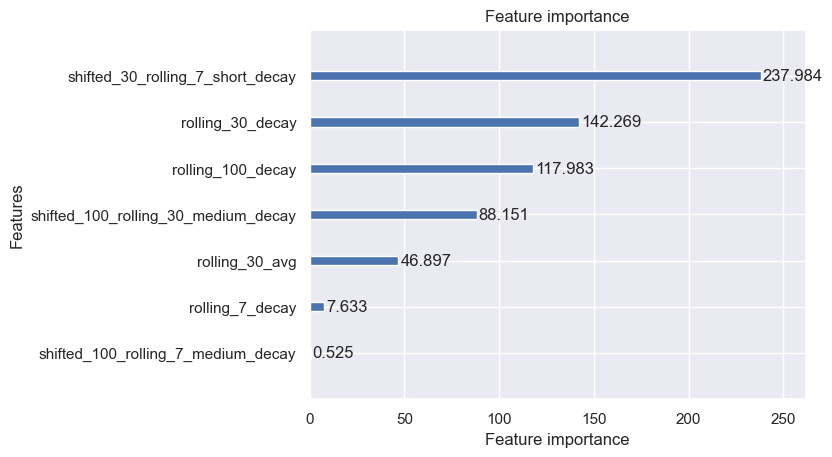

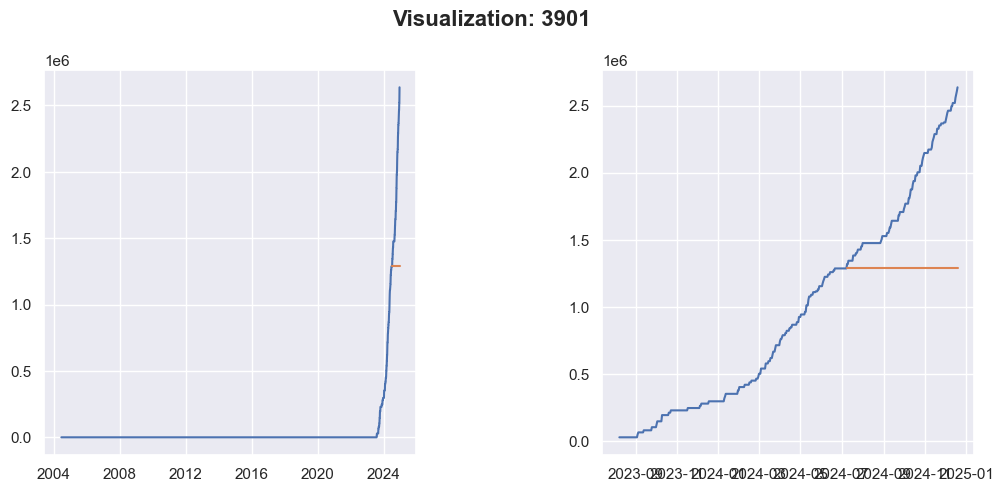

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0          0.0
1       9233.0
2          0.0
3          0.0
4          0.0
        ...   
159        0.0
160    10720.0
161        0.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays
0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:25,835] A new study created in memory with name: no-name-bb514733-6815-487b-aae3-64602e438d50
[I 2025-11-08 17:13:25,965] Trial 0 finished with value: 33064.21136041781 and parameters: {'learning_rate': 0.01136932247318583, 'num_leaves': 40, 'min_data_in_leaf': 91, 'feature_fraction': 0.7761488863274031, 'bagging_fraction': 0.7937765652411024, 'bagging_freq': 2, 'reg_alpha': 0.2443261559909773, 'reg_lambda': 0.9731552892539798}. Best is trial 0 with value: 33064.21136041781.
[I 2025-11-08 17:13:26,086] Trial 1 finished with value: 33057.25805579261 and parameters: {'learning_rate': 0.09060742669355323, 'num_leaves': 41, 'min_data_in_leaf': 40, 'feature_fraction': 0.5121476543446821, 'bagging_fraction': 0.5346703395356593, 'bagging_freq': 9, 'reg_alpha': 0.6499578757030724, 'reg_lambda': 0.028058542908494633}. Best is trial 1 with value: 33057.25805579261.
[I 2025-11-08 17:13:26,256] Trial 2 finished with value: 33064.56628688618 and parameters: {'learning_rate': 0.0

Best parameters: {'learning_rate': 0.061988086417682185, 'num_leaves': 76, 'min_data_in_leaf': 26, 'feature_fraction': 0.8608858395172961, 'bagging_fraction': 0.5796268796328937, 'bagging_freq': 10, 'reg_alpha': 0.4099983716828881, 'reg_lambda': 0.382393269810516}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10885.309350356347
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10885.452595793942
1


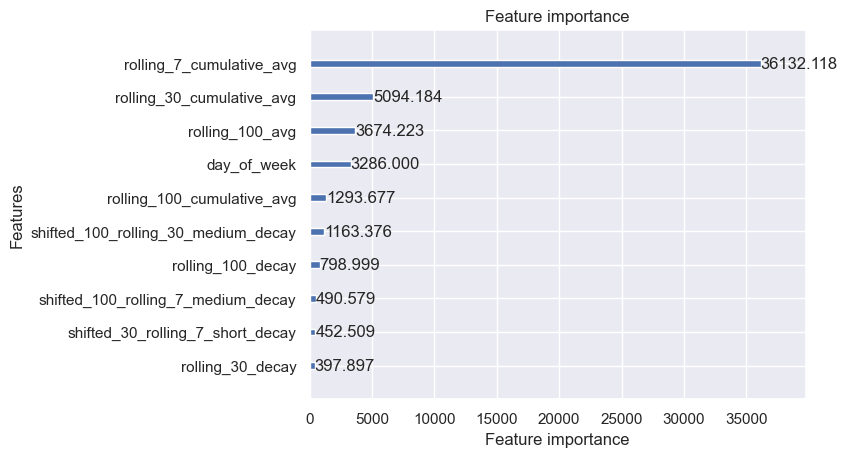

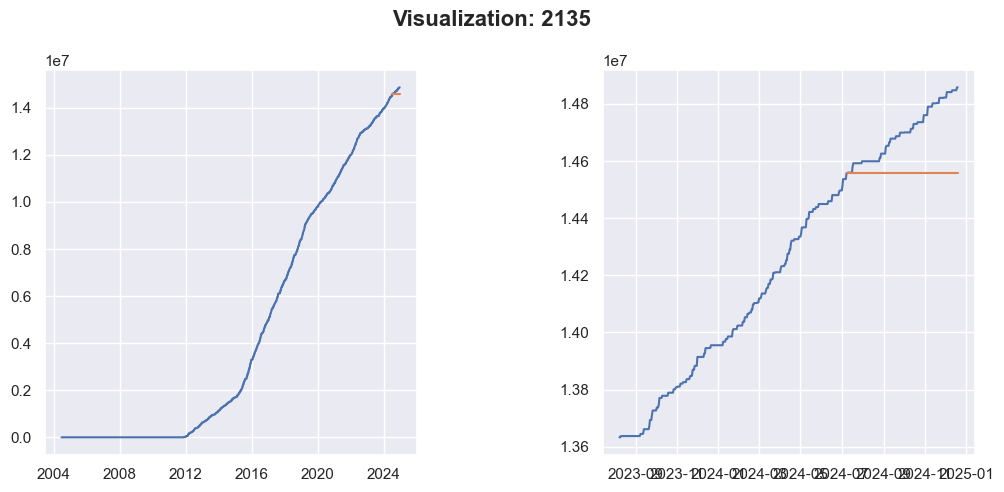

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0       1180.0
1      20950.0
2          0.0
3          0.0
4          0.0
        ...   
159        0.0
160        0.0
161        0.0
162        0.0
163        0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:13:31,135] A new study created in memory with name: no-name-b980e5e3-35f2-4e1c-bd1c-28f7e0103af2


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:31,235] Trial 0 finished with value: 21180.39146341463 and parameters: {'learning_rate': 0.09304707573383754, 'num_leaves': 61, 'min_data_in_leaf': 88, 'feature_fraction': 0.710254995388553, 'bagging_fraction': 0.7373505970374308, 'bagging_freq': 3, 'reg_alpha': 0.5493870882762375, 'reg_lambda': 0.14296506347794447}. Best is trial 0 with value: 21180.39146341463.
[I 2025-11-08 17:13:31,366] Trial 1 finished with value: 21180.39146341463 and parameters: {'learning_rate': 0.060850464782059015, 'num_leaves': 43, 'min_data_in_leaf': 46, 'feature_fraction': 0.5624212632163578, 'bagging_fraction': 0.9293199638234331, 'bagging_freq': 9, 'reg_alpha': 0.5813723230235615, 'reg_lambda': 0.746289978159608}. Best is trial 0 with value: 21180.39146341463.
[I 2025-11-08 17:13:31,446] Trial 2 finished with value: 21180.39146341463 and parameters: {'learning_rate': 0.07853258673754186, 'num_leaves': 85, 'min_data_in_leaf': 79, 'feature_fraction': 0.6167259185049272, 'bagging_fractio

Best parameters: {'learning_rate': 0.0994276955417153, 'num_leaves': 22, 'min_data_in_leaf': 15, 'feature_fraction': 0.6398643812796329, 'bagging_fraction': 0.8737269557842187, 'bagging_freq': 3, 'reg_alpha': 0.3871666372375468, 'reg_lambda': 0.0015705339148975022}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10885.452595793942
baseline correct:  102.61365213202623
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10886.076145381752
1


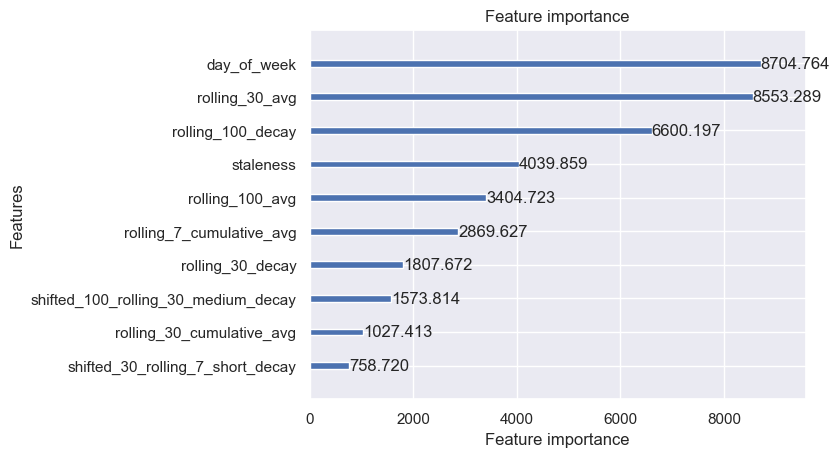

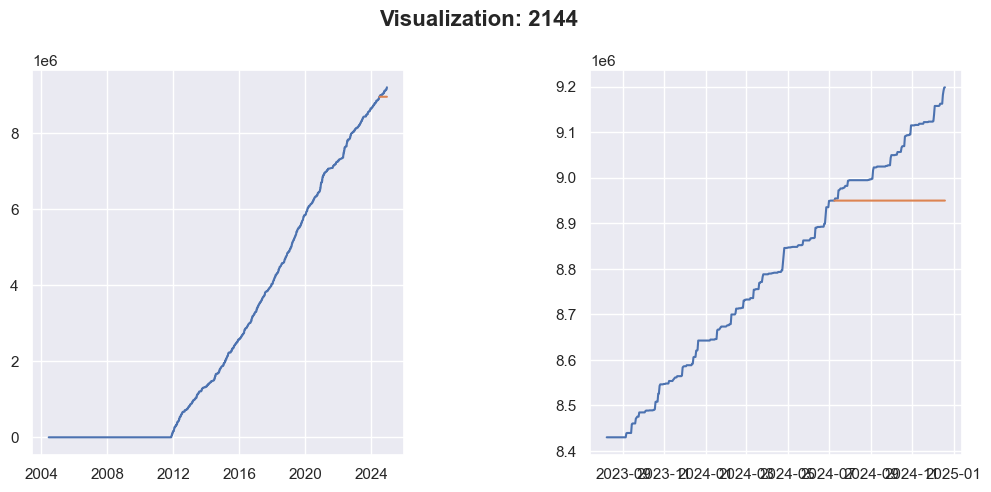

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
159    0.0
160    0.0
161    0.0
162    0.0
163    0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:13:35,218] A new study created in memory with name: no-name-a4800c57-7df6-4307-93d7-1342c96b320d
[I 2025-11-08 17:13:35,256] Trial 0 finished with value: 37000.320731707325 and parameters: {'learning_rate': 0.051556257504266796, 'num_leaves': 53, 'min_data_in_leaf': 48, 'feature_fraction': 0.8267709347200327, 'bagging_fraction': 0.6211286738797152, 'bagging_freq': 2, 'reg_alpha': 0.701104856958471, 'reg_lambda': 0.41058624831706136}. Best is trial 0 with value: 37000.320731707325.
[I 2025-11-08 17:13:35,294] Trial 1 finished with value: 37000.320731707325 and parameters: {'learning_rate': 0.08928532932739024, 'num_leaves': 38, 'min_data_in_leaf': 100, 'feature_fraction': 0.6883900225275708, 'bagging_fraction': 0.6811406762291262, 'bagging_freq': 5, 'reg_alpha': 0.1549945455816517, 'reg_lambda': 0.8132351748995643}. Best is trial 0 with value: 37000.320731707325.


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:35,333] Trial 2 finished with value: 37000.320731707325 and parameters: {'learning_rate': 0.020202557454032433, 'num_leaves': 77, 'min_data_in_leaf': 41, 'feature_fraction': 0.552897689937609, 'bagging_fraction': 0.8161268243056627, 'bagging_freq': 4, 'reg_alpha': 0.8276527046716243, 'reg_lambda': 0.016444691519570953}. Best is trial 0 with value: 37000.320731707325.
[I 2025-11-08 17:13:35,374] Trial 3 finished with value: 37000.320731707325 and parameters: {'learning_rate': 0.0247887983483098, 'num_leaves': 49, 'min_data_in_leaf': 25, 'feature_fraction': 0.5152028446742682, 'bagging_fraction': 0.712928664885458, 'bagging_freq': 10, 'reg_alpha': 0.7262446105104958, 'reg_lambda': 0.34687247402118737}. Best is trial 0 with value: 37000.320731707325.
[I 2025-11-08 17:13:35,482] Trial 4 finished with value: 37000.320731707325 and parameters: {'learning_rate': 0.0219050798376505, 'num_leaves': 76, 'min_data_in_leaf': 13, 'feature_fraction': 0.5374711677340657, 'bagging_f

Best parameters: {'learning_rate': 0.051556257504266796, 'num_leaves': 53, 'min_data_in_leaf': 48, 'feature_fraction': 0.8267709347200327, 'bagging_fraction': 0.6211286738797152, 'bagging_freq': 2, 'reg_alpha': 0.701104856958471, 'reg_lambda': 0.41058624831706136}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10886.076145381752
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10886.076145381752
1


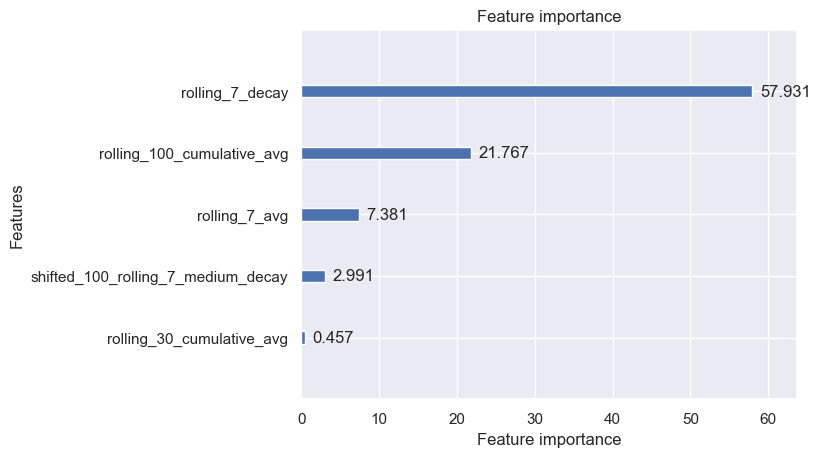

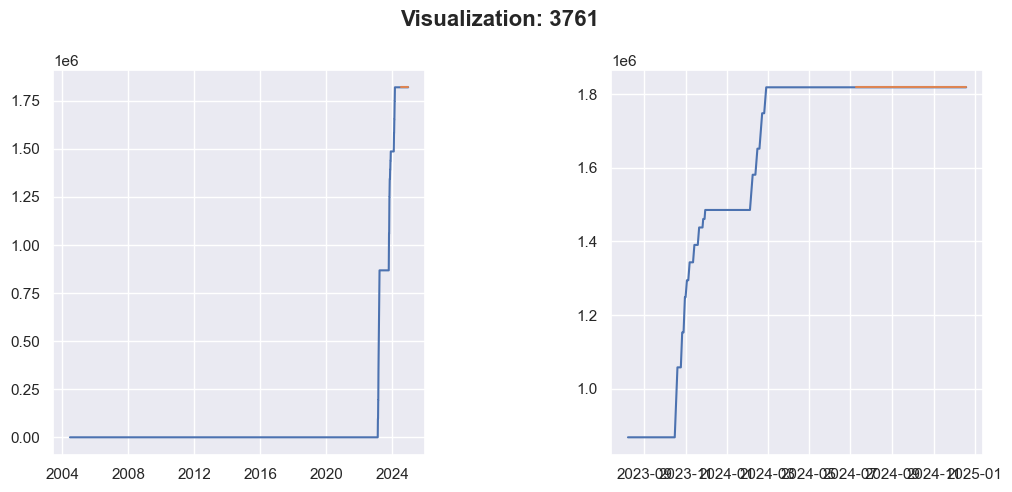

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
159    0.0
160    0.0
161    0.0
162    0.0
163    0.0
Name: daily_weight, Length: 164, dtype: float64
12  days are marked as holidays


[I 2025-11-08 17:13:37,357] A new study created in memory with name: no-name-59cb85f8-bc6e-40e4-b6d4-0127e690cbfe
[I 2025-11-08 17:13:37,431] Trial 0 finished with value: 11786.512195121952 and parameters: {'learning_rate': 0.0679833738908577, 'num_leaves': 54, 'min_data_in_leaf': 26, 'feature_fraction': 0.7864331319820077, 'bagging_fraction': 0.9686711754883626, 'bagging_freq': 4, 'reg_alpha': 0.4728596259062141, 'reg_lambda': 0.7944670961701851}. Best is trial 0 with value: 11786.512195121952.


0  days are marked as holidays
split data: Check!


[I 2025-11-08 17:13:37,503] Trial 1 finished with value: 11786.512195121952 and parameters: {'learning_rate': 0.04906034317167712, 'num_leaves': 28, 'min_data_in_leaf': 26, 'feature_fraction': 0.6938257661423665, 'bagging_fraction': 0.830272699185499, 'bagging_freq': 4, 'reg_alpha': 0.38181253970861895, 'reg_lambda': 0.409404502451191}. Best is trial 0 with value: 11786.512195121952.
[I 2025-11-08 17:13:37,562] Trial 2 finished with value: 11786.512195121952 and parameters: {'learning_rate': 0.02693125812838014, 'num_leaves': 96, 'min_data_in_leaf': 88, 'feature_fraction': 0.9700052490080238, 'bagging_fraction': 0.786085403676984, 'bagging_freq': 10, 'reg_alpha': 0.6392026499462216, 'reg_lambda': 0.3954993531778377}. Best is trial 0 with value: 11786.512195121952.
[I 2025-11-08 17:13:37,806] Trial 3 finished with value: 11786.512452605264 and parameters: {'learning_rate': 0.0737647070516511, 'num_leaves': 43, 'min_data_in_leaf': 12, 'feature_fraction': 0.643975497807566, 'bagging_fract

Best parameters: {'learning_rate': 0.0679833738908577, 'num_leaves': 54, 'min_data_in_leaf': 26, 'feature_fraction': 0.7864331319820077, 'bagging_fraction': 0.9686711754883626, 'bagging_freq': 4, 'reg_alpha': 0.4728596259062141, 'reg_lambda': 0.7944670961701851}
test- fit model: Check!
test- apply predict to map: Check!
retrieved evaluation files from files
test- initialize evaluation file: Check!
Initial test evaluated. Error:  10886.076145381752
baseline correct:  0.0
test- add predictions to evaluation file: Check!
Initial test evaluated. Error:  10886.076145381752
1


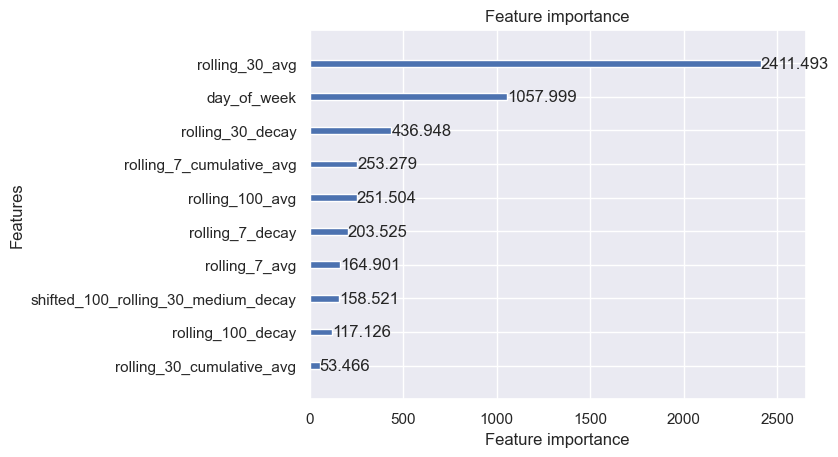

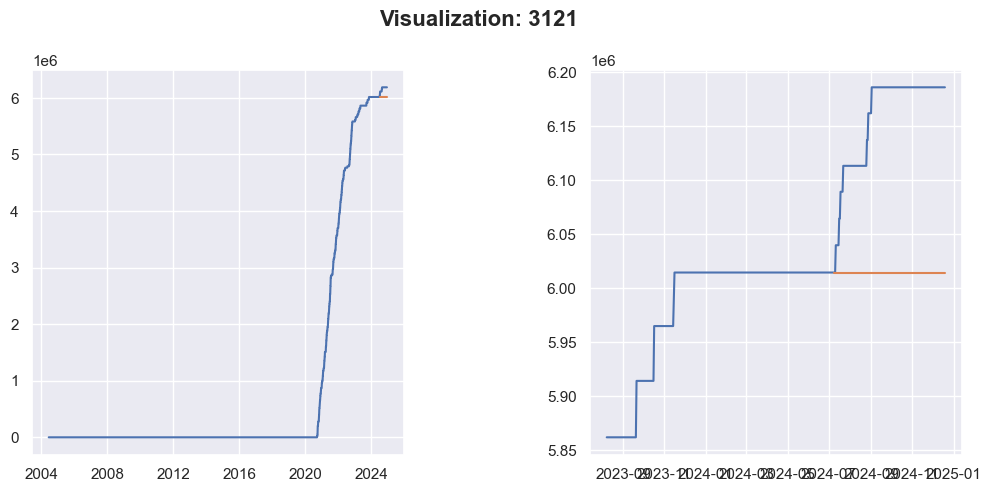

In [503]:
important_days = 1000
for i in range(0,20):
    important_ids=(range(i,i+1,1))
    run(clean_df, important_days, important_ids, feature_columns, target)
#for i in range(0,5):
#    important_ids=(range(10+3*i,13+3*i),1)
#    run(clean_df, important_days, important_ids, feature_columns, target)